# PyTorch Tutorial: Seq2Seq for Machine Translation (and a Mystery Language)

This notebook implements a **vanilla encoder–decoder LSTM seq2seq model** for machine translation.
It focuses on the basic ingredients of seq2seq without attention: how to represent sentences,
train a model with teacher forcing, and evaluate its translations.

We work with a small multi-parallel corpus containing sentences in:

- Danish  
- English  
- German  
- Finnish  
- Spanish  
- A “mystery” coded language

This data was adapted from the [European Parliament Proceedings Parallel Corpus 1996–2011](https://www.statmt.org/europarl/).

The notebook has two main goals:

1. **Build and inspect a vanilla seq2seq translation model (English → Spanish)**  
   - Load and preprocess parallel English–Spanish data  
   - Build vocabularies and PyTorch `Dataset` / `DataLoader` objects  
   - Implement an encoder–decoder LSTM **without attention**  
   - Train the model with teacher forcing, dropout, and validation monitoring  
   - Visualize training vs validation loss  
   - Evaluate with `sacrebleu` and inspect example translations  
     (including variants with and without `<UNK>` filtering)  

2. **Use seq2seq translation models to identify the mystery language**  
   - For each candidate source language (Danish, English, German, Finnish, Spanish),
     train a seq2seq model to translate from that language into the mystery language  
   - Compute BLEU scores on held-out test data for each (candidate → mystery) pair  
   - Compare scores to determine which candidate language is most compatible with the mystery stream  
   - Interpret the results in terms of a codebook-style cipher built on top of an unknown language.

By the end of the notebook, you will have:

- A working **vanilla seq2seq** translation model for English → Spanish  
- Plots of training and validation loss for multiple language pairs  
- BLEU-based evidence of which language the “mystery” stream is a systematically encoded version of  
- A baseline model that can later be extended with attention in a separate notebook

## TO RUN THIS NOTEBOOK YOU MUST MAKE THE DATA FILES AVAILABLE

For this notebook we use pre-tokenized parallel sentences stored in three
pickled dictionaries:

- `mt_train_sentences.pkl`  
- `mt_val_sentences.pkl`  
- `mt_test_sentences.pkl`

Each file is a Python `dict` mapping language names to lists of tokenized
sentences, for example:

- `"english"` → list of English sentences (each as a list of tokens)  
- `"spanish"` → list of Spanish sentences  
- `"danish"`, `"german"`, `"finnish"`, `"mystery"`, etc.

> Folder structure:  
> Put all three `.pkl` files into a folder called `data` in the same directory
> as this notebook:
>
> ```text
> your_project/
> ├── translation_attention.ipynb
> └── data/
>     ├── mt_train_sentences.pkl
>     ├── mt_val_sentences.pkl
>     └── mt_test_sentences.pkl
> ```
>
> The loading code expects paths like:
>
> ```python
> with open("data/mt_train_sentences.pkl", "rb") as f:
>     train_dict = pickle.load(f)
> ```

Once these files are in place, we can:

- Load the three dictionaries for train/validation/test.
- Build vocabularies over the chosen source and target languages.
- Wrap the tokenized sentence pairs in a `TranslationDataset` and use PyTorch
  `DataLoader`s (with a custom collate function) to produce padded tensors that
  will be fed into our seq2seq model.


# 1. Foundations

## What is a seq2seq model?

In this notebook we use a classic **encoder–decoder “sequence-to-sequence” (seq2seq) model** built from LSTMs.

At a high level, a seq2seq model:

- Uses an **encoder** network to read the entire source sentence and compress it into a fixed-size hidden state.
- Uses a **decoder** network to generate the target sentence one token at a time.
- Passes information from encoder to decoder via the encoder’s final hidden (and cell) state.
- Is trained with **teacher forcing**: during training, the decoder sees the *true* previous target token as input.

More concretely:

1. The encoder LSTM reads a padded sequence of source token IDs of shape `(batch_size, T_enc)` and produces:
   - A sequence of encoder hidden states of shape `(batch_size, T_enc, hidden_size)`, and
   - A final hidden and cell state of shape `(batch_size, hidden_size)`.
2. The decoder LSTM starts from the encoder’s final hidden and cell state and takes as input a padded sequence of
   previous target tokens (shifted right). It outputs:
   - A sequence of decoder hidden states of shape `(batch_size, T_dec, hidden_size)`.
3. A final linear layer maps each decoder hidden state to a vector of logits over the target vocabulary, so we can
   predict the most likely next token at each time step.

In more advanced variants (covered in a separate notebook) you can augment this basic architecture with mechanisms
that let the decoder “look back” at different parts of the encoder sequence. In this notebook, however,
we stick to the simplest encoder–decoder design to keep the focus on the core seq2seq ideas.


## Does translation direction matter (A→B vs B→A)?

Even when we use the same architecture and the same number of parallel sentences, we should *not* expect a seq2seq model to perform identically in both directions (A→B vs B→A). Natural languages are not in a neat one-to-one correspondence: vocabulary sizes differ, phrases of length $N$ in one language may map to phrases of length $M$ in the other, and some semantic distinctions that are lexicalized in one language are collapsed or paraphrased in the other.

This often makes one direction more “lossy” than the other. For example, in Spanish the word `prima` means “female cousin.” In real usage, translating to English, this would usually just become `cousin`, because explicitly saying “female cousin” (“I went for a walk with my female cousin”) sounds marked or awkward. A seq2seq model trained on actual usage would likely learn the more natural `prima → cousin` mapping. But now, going back from English to Spanish, the model has to choose between `prima` (female) and `primo` (male), even though that gender information was thrown away when we went into English.

In the other direction, consider the English phrasal verb `look forward to`, which has no single-word equivalent in Spanish. A very common translation is `esperar`, which can mean “to wait” or “to hope,” so “I’m looking forward to seeing you” often becomes something like “espero verte.” Information is lost: “looking forward” implies positive anticipation and high likelihood, not just desire. Testing this in Google Translate is interesting, as the translations reach a sort of equilibrium where the phrase is mutually translatable after the information loss has occurred. In this example in Google Translate, `I look forward to seeing you` → `Espero verte pronto` → `I hope to see you soon`.

These examples illustrate the general point: because languages differ in how granular or coarse their lexical choices are, and because some semantic distinctions cannot be perfectly preserved, the A→B mapping and the B→A mapping do not have the same difficulty. As a result, we should not expect a seq2seq model to achieve the same performance range in both directions, even on the same parallel corpus.

## What happens if we scramble all the characters?

Consider a word-level seq2seq model trained on a parallel corpus. What happens if we systematically scramble the characters in the source language before tokenization?

### **Case 1: Scramble characters, but never introduce whitespace**

In the first scenario, we replace every distinct non-whitespace character in the source language with a different distinct non-whitespace character. For example, `h → s`, `e → w`, `l → o`, `o → x`, so that `"hello"` becomes `"swoox"`. The mapping is one-to-one and never produces spaces.

From the model’s perspective, nothing fundamental has changed. It still sees a sequence of *word tokens* separated by whitespace, and the vocabulary is the same size—each original word just has a different spelling. During training, the model can learn embeddings for `"swoox"` that play the same role `"hello"` used to play. Since translation operates on a per-word basis and we haven’t created new word boundaries, we should expect performance to be essentially unchanged.

Another way to see this is to notice that this is just a simple substitution cipher at the character level (like a Caesar cipher). Frequency analysis can recover the original text because the distribution of words and their co-occurrences is untouched. All we’ve done is rename the characters; the underlying sentences and their meanings are the same, so a word-level seq2seq model can, in principle, learn exactly the same mapping.

### **Case 2: Scramble characters and allow whitespace**

In the second scenario, we again replace every distinct character with a different distinct character, but now the replacement may include whitespace. That is, some letters might be turned into spaces. The mapping is still one-to-one at the character level, but now a single original word can be transformed into multiple whitespace-separated chunks.

If the language uses spaces as word delimiters (like English, Spanish, etc.), this is a big problem: tokenization changes. A single word in the original corpus can become several “words” in the scrambled corpus, and the one-to-one correspondence between source words and their scrambled forms is broken. For example, imagine the letter `p` is mapped to a space:

- Original: `I own a campsite`
- After mapping `p → space` (before we scramble the other characters):  
  `I own a cam site`  
  Now `campsite` has been split into `cam` and `site`, which clearly has a different meaning.
- After scrambling the remaining letters into other non-whitespace symbols, we still see that the tokenization pattern differs (e.g., `O gcf a ead lomt` vs something like `O gcf a eadhlomt` if no space had been introduced).

For a space-delimited language, this means:

- The model now has to learn mappings from longer, more fragmented source sequences to target sentences.
- The neat word-level correspondences in the original parallel data are replaced by more complex many-token-to-one-word mappings.
- Semantic cues that were neatly packaged in single word tokens are now scattered across multiple tokens.

Once whitespace can be generated by the scrambling, “single words become multiple words,” and the clean one-to-one mapping at the word level is lost. This makes the translation task strictly harder, so we should expect performance to decrease in this second scenario.

# 2. Machine Translation: Sequence-to-sequence translation (vanilla seq2seq)

In this part of the notebook we will build and experiment with a neural machine translation system implemented in PyTorch. The core building block is an RNN-based encoder–decoder model with LSTM units.

The encoder reads a source sentence one token at a time and produces a sequence of hidden states; the decoder then generates the target sentence one word at a time from the encoded representation.

We will first train this model on an English → Spanish parallel corpus, monitor train/validation loss, and inspect example translations to see what the model has learned. Then we will reuse exactly the same architecture to translate from several different candidate source languages into a `mystery` language, compare their BLEU scores, and use those results to reason about what the mystery language must be. Along the way, you will see how the encoder and decoder components work together in a practical, end-to-end translation system.

In [ ]:
# Core Python and typing utilities
import copy
import pickle
import random
import subprocess
import sys
from typing import Dict, List, Tuple

# Data science and plotting libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# PyTorch components
import torch
from torch import as_tensor, nn, optim
from torch.nn import BCEWithLogitsLoss, CrossEntropyLoss
from torch.nn.utils.rnn import (
    pack_padded_sequence,
    pad_packed_sequence,
    pad_sequence,
)
from torch.utils.data import DataLoader, Dataset
from torch.optim import Adam

# BLEU evaluation (install sacrebleu on the fly if needed)
try:
    import sacrebleu
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "sacrebleu"])
    import sacrebleu

## Machine translation Setup

We will now put a vanilla encoder–decoder seq2seq model to work on a genuine sequence-to-sequence task: machine translation.

Our plan is:

- First, train the model on an English → Spanish parallel corpus to understand its behavior on a single language pair (loss curves, example translations, BLEU scores).
- Then, reuse the same architecture to translate from several different candidate source languages into a `mystery` language, and compare their BLEU scores. The relative performance across language pairs will help us reason about the identity of the mystery language.

### Parallel translation data

For these experiments, we use pre-tokenized, pickled datasets.  
Each split is stored in a separate file ([documentation on what Pickling is](https://docs.python.org/3/library/pickle.html)):

- `mt_train_sentences.pkl`
- `mt_val_sentences.pkl`
- `mt_test_sentences.pkl`

Each file contains a Python dictionary mapping language names to lists of tokenized sentences. The available languages are:

- Danish
- English
- German
- Finnish
- Spanish
- `mystery` (an obfuscated or lossy encoded language)

The general structure of each file looks like this:

```python
{
    "danish": [
        ["token", "token", "token", ...],
        ["token", "token", "token", ...],
        ...
    ],
    "english": [
        ["token", "token", "token", ...],
        ["token", "token", "token", ...],
        ...
    ],
    "mystery": [
        ["token", "token", "token", ...],
        ["token", "token", "token", ...],
        ...
    ],
    # etc.
}
````

The key indicates the language, and the *n*-th sentence in each list forms a parallel set of translations across languages. For example, entry `i` in `"english"` and entry `i` in `"spanish"` are translations of the same underlying sentence; likewise for `"english"` and `"mystery"`, `"danish"` and `"mystery"`, and so on.

In the code below, we will:

* Load these pickled dictionaries for the train, validation, and test splits.
* Build vocabularies from the tokenized sentences.
* * Create PyTorch `Dataset` and `DataLoader` objects that yield padded
  mini-batches suitable for our seq2seq model.

As you go, it’s worth inspecting a few batches from the dataloaders (for example, `next(iter(train_loader))`) to get an intuition for what the model actually sees during training.


### Building vocabularies

The helpers below are used to turn raw tokenized sentences into vocabularies that our models can work with.

- `get_word_counts` computes how often each token appears in a corpus.  
  We use these counts to tell us which words are common enough to keep as separate entries, and which are so rare that it’s better to group them into a single `<UNK>` (unknown) token. This keeps the vocabulary manageable and reduces overfitting to one-off typos or extremely rare words.
- `generate_vocab` then assigns each token an integer ID, reserving special indices for `<PAD>`, `<EOS>`, and `<UNK>`, and mapping very rare tokens to `<UNK>` based on `min_freq`.

Later, we’ll use these vocabularies to convert sentences into sequences of indices for our embedding layers and dataloaders.


In [ ]:
# Special token indices used throughout the notebook
PADDING_IDX = 0   # padding for shorter sequences in a batch
EOS_IDX = 1       # end-of-sequence marker
UNK_IDX = 2       # out-of-vocabulary / rare words

# Helper functions for building vocabularies from tokenized text

def get_word_counts(sentences: List[List[str]]) -> Dict[str, int]:
    """
    Count token frequencies in a tokenized corpus.

    Args:
        sentences: List of sentences, where each sentence is a list of tokens.

    Returns:
        A dictionary mapping each token to its frequency in the corpus.
    """
    word_counts: Dict[str, int] = {}
    for sent in sentences:
        for word in sent:
            if word in word_counts:
                word_counts[word] += 1
            else:
                word_counts[word] = 1
    return word_counts


def generate_vocab(word_counts: Dict[str, int], min_freq: int) -> Tuple[Dict[str, int], int]:
    """
    Build a token → index vocabulary from token frequency counts.

    Args:
        word_counts: A dictionary mapping tokens to their counts.
        min_freq:    Minimum frequency required for a token to be kept
                     as its own entry in the vocabulary. Tokens that occur
                     <= min_freq times are mapped to <UNK>.

    Returns:
        vocab:    A dictionary mapping tokens to integer indices.
        vocab_sz: The size of the vocabulary (number of distinct indices).
    """
    # Sort tokens by descending frequency
    sorted_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)

    # Reserve indices 0, 1, 2 for special tokens (<PAD>, <EOS>, <UNK>)
    vocab = {
        word: i + 3
        for i, (word, count) in enumerate(sorted_words)
        if count > min_freq
    }

    # Add special tokens
    vocab["<PAD>"] = PADDING_IDX
    vocab["<EOS>"] = EOS_IDX
    vocab["<UNK>"] = UNK_IDX

    return vocab, len(vocab)



### Loading parallel data and building a translation dataset

We now load the parallel translation data for the train, validation, and test splits from the pickled dictionaries described above. For our first experiment, we will focus on the English → Spanish pair.

The `TranslationDataset` class wraps these tokenized sentence pairs into a PyTorch `Dataset`:

- On the training split, it builds separate source and target vocabularies from word counts (using `min_freq` to decide which words become `<UNK>`).
- On the validation and test splits, it reuses the same vocabularies as the training set so that indices are consistent across splits.
- The `_get_idx_dataset` helper converts token sequences to index sequences and appends/ prepends special `<EOS>` markers:
  - Source sentences get an `<EOS>` token at the end.
  - Target sentences get `<EOS>` both at the beginning (used as a start-of-sequence token) and at the end.

At the end, we create three dataset objects: `train_ds`, `val_ds`, and `test_ds` for English → Spanish translation.


In [ ]:
# Load tokenized parallel sentences for each split
with open("data/mt_train_sentences.pkl", "rb") as f:
    train_dict = pickle.load(f)

with open("data/mt_val_sentences.pkl", "rb") as f:
    val_dict = pickle.load(f)

with open("data/mt_test_sentences.pkl", "rb") as f:
    test_dict = pickle.load(f)


class TranslationDataset(Dataset):
    """
    A simple dataset for parallel sentence pairs (source → target).

    If no vocabularies are provided, this dataset will:
      - Build a source vocabulary from the source sentences.
      - Build a target vocabulary from the target sentences.

    If vocabularies are provided (e.g., for val/test), it will reuse them
    so that token indices are consistent across splits.
    """

    def __init__(
        self,
        source: List[List[str]],
        target: List[List[str]],
        min_freq: int = 1,
        source_vocab: Dict[str, int] | None = None,
        target_vocab: Dict[str, int] | None = None,
    ) -> None:
        super().__init__()

        # Build vocabularies from scratch (typically for the training set)
        if source_vocab is None and target_vocab is None:
            self.source_vocab, self.source_vocab_size = generate_vocab(
                get_word_counts(source),
                min_freq,
            )
            self.target_vocab, self.target_vocab_size = generate_vocab(
                get_word_counts(target),
                min_freq,
            )
        else:
            # Reuse existing vocabularies (for validation / test)
            self.source_vocab = source_vocab
            self.source_vocab_size = len(source_vocab)

            self.target_vocab = target_vocab
            self.target_vocab_size = len(target_vocab)

        # Convert all token sequences to index sequences once up front
        self.source, self.target = self._get_idx_dataset(
            source,
            target,
            self.source_vocab,
            self.target_vocab,
        )

    def __len__(self) -> int:
        return len(self.target)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Return a single (source_indices, target_indices) pair as tensors.
        """
        return torch.tensor(self.source[idx]), torch.tensor(self.target[idx])

    def _get_idx_dataset(
        self,
        source: List[List[str]],
        target: List[List[str]],
        source_vocab: Dict[str, int],
        target_vocab: Dict[str, int],
    ) -> Tuple[List[List[int]], List[List[int]]]:
        """
        Map tokenized source/target sentences to index sequences, adding EOS markers.

        - Source sentences: [w1, w2, ..., wN, <EOS>]
        - Target sentences: [<EOS>, w1, w2, ..., wM, <EOS>]
          (here we reuse <EOS> as a start-of-sequence token for the decoder)
        """
        source_toks: List[List[int]] = []
        target_toks: List[List[int]] = []

        for src, tar in zip(source, target):
            # Map source tokens to indices, then append EOS
            src_ids = [
                source_vocab[token]
                if token in source_vocab
                else source_vocab["<UNK>"]
                for token in src
            ]
            src_ids.append(source_vocab["<EOS>"])

            # For the target, prepend EOS as a start token, then map tokens, then append EOS
            tar_ids = [target_vocab["<EOS>"]]
            tar_ids.extend(
                target_vocab[token]
                if token in target_vocab
                else target_vocab["<UNK>"]
                for token in tar
            )
            tar_ids.append(target_vocab["<EOS>"])

            source_toks.append(src_ids)
            target_toks.append(tar_ids)

        return source_toks, target_toks


# English → Spanish datasets for our first experiment
train_ds = TranslationDataset(
    train_dict["english"],
    train_dict["spanish"],
)

test_ds = TranslationDataset(
    test_dict["english"],
    test_dict["spanish"],
    source_vocab=train_ds.source_vocab,
    target_vocab=train_ds.target_vocab,
)

val_ds = TranslationDataset(
    val_dict["english"],
    val_dict["spanish"],
    source_vocab=train_ds.source_vocab,
    target_vocab=train_ds.target_vocab,
)

### Inspecting parallel examples across languages

Before training the model, it helps to sanity-check the parallel corpus and see how sentences align across languages so that we can make sure everything is lined up, and see if we can even recognize our "mystery language" (spoiler alert–we can't).

The helper function below, `show_parallel_examples`, prints a few parallel sentence sets from one of the splits (`train_dict`, `val_dict`, or `test_dict`). For each selected index, it shows the corresponding sentence in:

- Danish  
- English  
- German  
- Finnish  
- Spanish  
- `mystery`

You can either sample random indices (using an optional random seed for reproducibility) or view the first few examples in order. This is helpful for:

- Confirming that all language lists have the same length and are truly aligned.
- Getting an intuition for what the `mystery` language looks like relative to the others (gobbledy-gook!)


In [ ]:
# Utility to inspect aligned sentences across all languages in a split
def show_parallel_examples(
    data_dict: Dict[str, List[List[str]]],
    n_examples: int = 5,
    random_sample: bool = True,
    seed: int | None = None,
) -> None:
    """
    Print a few parallel sentence sets across all explicit languages plus the
    mystery language, using the provided data_dict (e.g., train_dict, val_dict,
    or test_dict).

    Args:
        data_dict:      Dictionary mapping language names to lists of tokenized
                        sentences (as loaded from the .pkl files).
        n_examples:     Number of parallel examples to display.
        random_sample:  If True, sample random indices; if False, use the first
                        n_examples in order.
        seed:           Optional random seed for reproducible sampling.
    """
    langs = ["danish", "english", "german", "finnish", "spanish", "mystery"]
    pretty = {
        "danish":  "Danish",
        "english": "English",
        "german":  "German",
        "finnish": "Finnish",
        "spanish": "Spanish",
        "mystery": "Mystery",
    }

    num_sentences = len(data_dict["english"])
    n_examples = min(n_examples, num_sentences)

    if seed is not None:
        random.seed(seed)

    # Choose which sentence indices to display
    if random_sample:
        indices = random.sample(range(num_sentences), n_examples)
    else:
        indices = list(range(n_examples))

    print("=== Parallel examples across languages ===")
    for ex_idx, sent_idx in enumerate(indices, start=1):
        print(f"\n--- Example {ex_idx} (index {sent_idx}) ---")
        for lang in langs:
            tokens = data_dict[lang][sent_idx]
            text = " ".join(tokens)
            print(f"{pretty[lang]}: {text}")
        print("-" * 60)


# Example: inspect a few random parallel sentences from the test split
show_parallel_examples(
    test_dict,
    n_examples=5,
    random_sample=True,
    seed=42,
)


=== Parallel examples across languages ===

--- Example 1 (index 654) ---
Danish: jeg er sikker på at den får positive virkninger for bulgarien og rumænien
English: i am convinced that it will be positive for bulgaria and romania
German: ich bin sicher dass sie für bulgarien und rumänien positiv sein wird
Finnish: olen vakuuttunut siitä että laajentumisesta tulee myönteinen asia myös bulgarialle ja romanialle
Spanish: estoy seguro de sus efectos positivos para bulgaria y rumanía
Mystery: rac neki izjk f hov khv qxmaj op xufg bws s ot
------------------------------------------------------------

--- Example 2 (index 114) ---
Danish: i er hverken interesseret i demokrati eller ægte demokratiske valg
English: you are not interested in democracy or genuine democratic elections
German: sie sind an demokratie bzw echten demokratischen wahlen nicht interessiert
Finnish: te ette ole kiinnostuneita demokratiasta tai aidosti demokraattisista vaaleista
Spanish: a ustedes no les interesan ni la de

### Collation and padding for variable-length sequences

In our translation dataset, each source and target sentence can have a different length. However, PyTorch models typically expect a batch to be a single tensor of shape `(batch_size, max_seq_len, ...)`, where all sequences in the batch are padded to the same length.

PyTorch’s `DataLoader` handles batching by:

1. Calling `__getitem__` on the dataset multiple times to get a list of individual samples.
2. Passing that list to a collate function, which decides how to turn the list into a single batch.

By default, the collate function just stacks tensors, which doesn’t work for variable-length sequences. Instead, we define a custom `pad_collate` that:

- Takes a list of `(source_tensor, target_tensor)` pairs.
- Pads all source sequences in the batch to the same length.
- Pads all target sequences in the batch to the same length.
- Returns two tensors: `padded_source` and `padded_target`, using `PADDING_IDX` as the padding value.

We’ll pass this function as `collate_fn` to our `DataLoader` so that every batch is properly padded for our seq2seq model.


In [ ]:
# Since this is for machine translation, we pad both source and target sequences
def pad_collate(
    batch: List[Tuple[torch.Tensor, torch.Tensor]]
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Collate function for variable-length (source, target) pairs.

    Args:
        batch: A list of samples from the dataset, where each sample is a tuple
               (source_indices, target_indices) of 1D tensors.

    Returns:
        padded_source: 2D tensor of shape (batch_size, max_src_len) with
                       all source sequences padded to the same length.
        padded_target: 2D tensor of shape (batch_size, max_tgt_len) with
                       all target sequences padded to the same length.

    Both use PADDING_IDX to fill in positions beyond the true sequence length.
    """
    # Unzip list of (source, target) into two lists
    source, target = zip(*batch)

    # Pad source and target sequences independently along the time dimension
    padded_source = pad_sequence(
        source,
        batch_first=True,
        padding_value=PADDING_IDX,
    )
    padded_target = pad_sequence(
        target,
        batch_first=True,
        padding_value=PADDING_IDX,
    )

    return padded_source, padded_target

### Building DataLoaders for training, validation, and testing

Now that we have:

- `TranslationDataset` objects (`train_ds`, `val_ds`, `test_ds`) that return
  `(source_indices, target_indices)` pairs, and
- a custom `pad_collate` function that pads variable-length sequences in a batch,

we can wrap each dataset in a PyTorch `DataLoader`.

The `DataLoader` is responsible for:

- Sampling indices from the dataset (optionally in random order for training).
- Calling `__getitem__` to fetch individual samples.
- Passing the list of samples to `collate_fn` (here, `pad_collate`) to turn them into a single batched tensor of source sequences and a batched tensor of target sequences.

Below, we create three dataloaders for the English → Spanish experiment: one for training, one for validation, and one for testing, all using a batch size of 32 and our custom collation function.

See the [docs](https://pytorch.org/docs/stable/data.html) for more details.

In [ ]:
# DataLoaders for English -> Spanish translation
train_dl = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    collate_fn=pad_collate,
)

val_dl = DataLoader(
    val_ds,
    batch_size=32,
    shuffle=True,
    collate_fn=pad_collate,
)

test_dl = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=True,
    collate_fn=pad_collate,
)

### LSTM encoder for the source sentence (with packed sequences)

The encoder is the first component of our seq2seq model. It reads the padded source sequence and produces:

- A final hidden state and cell state of shape `(batch_size, hidden_size)`  
  that summarize the entire source sentence and will be used to initialize the decoder.

We implement the encoder as an LSTM-based `nn.Module` with an `Embedding` layer followed by an `LSTM` (see the PyTorch [LSTM docs](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)). The key extra ingredient is how we handle padding with *packed* sequences.

#### Why do we “pack” sequences?

Our inputs are padded to a common length so they fit into a single tensor, but:

- Different sentences in a batch have different true lengths.
- The trailing `<PAD>` tokens are not real data and should not influence the LSTM’s hidden states.

Conceptually, a *packed sequence* is just a padded batch plus the true lengths, wrapped in a special object so PyTorch knows which time steps are real tokens and which are padding. This gives us two benefits at once:

1. **Efficiency**  
   When we call [`pack_padded_sequence`](https://pytorch.org/docs/stable/generated/torch.nn.utils.rnn.pack_padded_sequence.html), PyTorch creates a compact representation that lets the LSTM skip over the padded positions. It doesn’t waste computation on the trailing `<PAD>` tokens in each sequence.

2. **Correct handling of variable-length sequences**  
   Because we also pass in the true lengths, PyTorch knows exactly where each sequence actually ends. That means:
   - The LSTM’s final hidden state for each example corresponds to the last *real* token, not to a padded time step.
   - The padded time steps are effectively ignored, rather than being treated as if they were part of the sentence.

Concretely, in the encoder we:

1. Start with an embedded, padded batch `embeds` of shape `(batch_size, max_seq_len, hidden_size)`.
2. Compute a length for each sequence (the number of non-padding tokens).
3. Call `pack_padded_sequence(embeds, lengths, batch_first=True, enforce_sorted=False)` to produce a packed representation.
4. Feed this packed representation into the LSTM and keep only the final hidden and cell states that come out of it.

Packing lets us work with variable-length sequences in a batch-friendly way: we keep the convenience of padded tensors, while telling PyTorch “these are the real tokens, these are padding! Please ignore the padding for both computation and sequence boundaries” when computing the encoder summary vectors.

In [ ]:
class EncoderLSTM(nn.Module):
    """
    LSTM-based encoder for the source sequence.

    This module:
      - Embeds token indices into dense vectors.
      - Runs them through an LSTM to produce a sequence of hidden states.
      - Returns the final hidden/cell states, which summarize the entire source
        sentence and will be used to initialize the decoder.
    """

    def __init__(
        self,
        input_size: int,
        hidden_size: int,
        padding_idx: int,
        dropout: float = 0.3,
    ) -> None:
        """
        Args:
            input_size:  Size of the source vocabulary (number of embeddings).
            hidden_size: Dimensionality of both the embeddings and LSTM hidden state.
            padding_idx: Index used for the <PAD> token (to be ignored in embeddings).
            dropout:     Dropout probability applied to the embeddings.
        """
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.padding_idx = padding_idx

        # Map token indices → dense vectors
        self.embedding = nn.Embedding(
            num_embeddings=input_size,
            embedding_dim=hidden_size,
            padding_idx=padding_idx,
        )

        # LSTM over the embedded sequence, with batch dimension first
        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            batch_first=True,
        )

        # Dropout on embeddings to reduce overfitting
        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        input_seqs: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Encode a batch of padded source sequences.

        Args:
            input_seqs: LongTensor of shape (batch_size, max_src_len) containing
                        token indices, padded with padding_idx.

        Returns:
            hidden: Tensor of shape (batch_size, hidden_size) with the
                    final hidden state for each sequence.
            cell:   Tensor of shape (batch_size, hidden_size) with the
                    final cell state for each sequence.
        """
        # Compute sequence lengths by counting non-padding tokens
        # (assumes padding_idx == 0, so nonzero positions are real tokens)
        lengths = as_tensor([torch.count_nonzero(x) for x in input_seqs])

        # Embed tokens and apply dropout
        embeds = self.dropout(self.embedding(input_seqs))

        # Pack the embedded sequences so the LSTM can skip padding positions
        packed_embeds = nn.utils.rnn.pack_padded_sequence(
            input=embeds,
            lengths=lengths,
            batch_first=True,
            enforce_sorted=False,  # we don't require the batch to be length-sorted
        )

        # Run through the LSTM; we only keep the final hidden/cell states
        _, (hidden, cell) = self.lstm(packed_embeds)

        # LSTM returns hidden/cell with shape (num_layers * num_directions, batch, hidden_size)
        # Here we use a single-layer, unidirectional LSTM, so we can squeeze the first dim.
        hidden = hidden.squeeze(0)  # (batch_size, hidden_size)
        cell = cell.squeeze(0)      # (batch_size, hidden_size)

        return hidden, cell

### LSTM decoder for the target sentence

The decoder is the second major component of our seq2seq model. It generates the target sentence one time step at a time, using:

- The final hidden and cell states from the encoder as its initial state.
- The previous target tokens (teacher forcing during training) as inputs.

In this notebook, the decoder is implemented as an LSTM-based `nn.Module` with:

- An `Embedding` layer over the target vocabulary.
- An `LSTM` that takes embedded target tokens and produces a sequence of decoder hidden states of shape `(batch_size, T_dec, hidden_size)`.

These decoder hidden states are then passed through a linear layer to produce a
distribution over the next target token.

The decoder’s `forward` method:

1. Takes a batch of target sequences `input_seqs` (typically shifted right for teacher forcing).
2. Embeds them with the target embedding layer.
3. Runs the embeddings through the LSTM, initialized with the encoder’s final hidden and cell states.
4. Returns:
   - The full sequence of decoder outputs over time (to be converted into
  vocabulary logits for each time step),
   - The final hidden state,
   - The final cell state.

In [ ]:
class DecoderLSTM(nn.Module):
    """
    LSTM-based decoder for the target sequence.

    This module:
      - Embeds target token indices into dense vectors.
      - Runs an LSTM over the embedded target sequence, initialized from the
        encoder's final hidden and cell states.
      - Returns the sequence of decoder hidden states plus the final hidden/cell.
    """

    def __init__(
        self,
        input_size: int,
        hidden_size: int,
        padding_idx: int,
        dropout: float = 0.0,
    ) -> None:
        """
        Args:
            input_size:  Size of the target vocabulary (number of embeddings).
            hidden_size: Dimensionality of both embeddings and LSTM hidden state.
            padding_idx: Index of the <PAD> token in the target vocabulary.
            dropout:     Dropout probability applied to target embeddings.
        """
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.padding_idx = padding_idx

        # Target-side embedding layer (for target token indices)
        self.embedding = nn.Embedding(
            num_embeddings=input_size,
            embedding_dim=hidden_size,
            padding_idx=padding_idx,
        )

        # LSTM over the embedded target sequence
        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            batch_first=True,
        )

        # Optional dropout on target embeddings
        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        input_seqs: torch.Tensor,
        hidden_init: torch.Tensor,
        cell_init: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Run the decoder over a batch of target sequences (teacher forcing).

        Args:
            input_seqs:  LongTensor [B, T_dec] with target token indices used
                         as inputs to the decoder (usually all but the last
                         token of the target sequence).
            hidden_init: Tensor [B, H] with the initial hidden state, usually
                         the encoder's final hidden state.
            cell_init:   Tensor [B, H] with the initial cell state, usually
                         the encoder's final cell state.

        Returns:
            output: Tensor [B, T_dec, H] with decoder hidden states at each step.
            hidden: Tensor [B, H] with the final hidden state.
            cell:   Tensor [B, H] with the final cell state.
        """
        # Embed target token indices and apply dropout
        embeds = self.dropout(self.embedding(input_seqs))
        # embeds: [B, T_dec, H]

        # LSTM expects initial states with shape [num_layers, B, H],
        # so we add a layer dimension via unsqueeze(0).
        output, (hidden, cell) = self.lstm(
            embeds,
            (hidden_init.unsqueeze(0), cell_init.unsqueeze(0)),
        )

        # output: [B, T_dec, H]
        # hidden: [1, B, H] → squeeze to [B, H]
        # cell:   [1, B, H] → squeeze to [B, H]
        return output, hidden.squeeze(0), cell.squeeze(0)

### Putting it all together: vanilla Seq2Seq

We now combine the encoder and decoder into a single `Seq2Seq` model.

At a high level:

- The **encoder** (`EncoderLSTM`) reads the source sentence and returns:
  - A final hidden state of shape `(B, H)`.
  - A final cell state of shape `(B, H)`.
  These two vectors summarize the entire source sentence in a fixed-size representation.
- The **decoder** (`DecoderLSTM`) takes:
  - The previous target tokens (teacher forcing during training),
  - The initial hidden and cell states from the encoder,
  - And produces a sequence of decoder hidden states of shape `(B, T_dec, H)`.

We then feed each decoder hidden state through a linear layer to obtain a distribution over the target vocabulary at each time step.

#### Training: `forward` with teacher forcing

During training, we use *teacher forcing*:

- Inputs:
  - `input_seqs`: padded source sentences of shape `(B, T_enc)`.
  - `output_seqs`: padded target sentences of shape `(B, T_dec + 1)` (including start and end markers).
- We feed `output_seqs[:, :-1]` into the decoder as inputs (everything except the last token), and train the model to predict `output_seqs[:, 1:]` (everything except the first token).
- The `forward` method does the following:
  1. Encode the source to obtain the final hidden and cell states.
  2. Decode the (shifted) target sequence using these initial encoder states.
  3. Project decoder hidden states to vocabulary logits.
  4. Mask out padding positions in the target.
  5. Return:
     - `preds`: a flattened tensor of shape `(M, V)` with logits for all non-pad target positions.
     - `targs`: a flattened tensor of shape `(M,)` with the corresponding true target token IDs.

Here, `M` is the total number of *non-padding* target tokens in the batch, and `V` is the target vocabulary size.

#### Inference: `generate` with greedy decoding

At inference time, we don’t know the true target sequence, so we can’t use teacher forcing. Instead, we:

1. Encode a single source sentence (shape `(T_enc,)`) to get the encoder’s final hidden and cell states.
2. Start the decoder with a designated start token (in this notebook, we reuse `<EOS>` as the first token).
3. At each step:
   - Run one decoder step given the previous token and the current hidden/cell state.
   - Project the decoder hidden state to vocabulary logits.
   - Take the argmax over the vocabulary (greedy decoding) to choose the next token.
   - Append the predicted token and feed it back in as the next input.
4. Stop when we generate an `eos_idx` token or when `max_steps` is reached.

The `generate` method implements this loop for a single example (no batching) and returns the generated token IDs as a 1D tensor.

In [ ]:
# Notation for shapes used below:
#   B      = batch size
#   T_enc  = length of the encoder (source) sequence
#   T_dec  = length of the decoder (target) sequence used as input
#   H      = hidden size / embedding dimension
#   V      = size of the target vocabulary


class Seq2Seq(nn.Module):
    """
    Full seq2seq model with LSTM encoder and LSTM decoder.

    - EncoderLSTM encodes the source sequence into a single vector:
        hidden, cell: [B, H]
    - DecoderLSTM takes target inputs (teacher forcing) and encoder final states to
      produce decoder hidden states:
        decoder_outputs: [B, T_dec, H]
    - A final linear layer maps decoder hidden states to vocabulary logits:
        logits: [B, T_dec, V]
    """

    def __init__(
        self,
        input_vocab_size: int,
        output_vocab_size: int,
        hidden_size: int,
        padding_idx: int,
    ) -> None:
        """
        Args:
            input_vocab_size:  Size of the source vocabulary.
            output_vocab_size: Size of the target vocabulary.
            hidden_size:       Dimensionality of encoder/decoder hidden states.
            padding_idx:       Index used for the <PAD> token.
        """
        super().__init__()
        self.input_vocab_size = input_vocab_size
        self.output_vocab_size = output_vocab_size
        self.hidden_size = hidden_size
        self.padding_idx = padding_idx

        # Encoder for the source sequence
        self.encoder = EncoderLSTM(
            input_size=input_vocab_size,
            hidden_size=hidden_size,
            padding_idx=padding_idx,
        )

        # Decoder for the target sequence
        self.decoder = DecoderLSTM(
            input_size=output_vocab_size,
            hidden_size=hidden_size,
            padding_idx=padding_idx,
        )

        # Final linear layer to map decoder states to vocabulary logits
        self.linear1 = nn.Linear(
            in_features=hidden_size,
            out_features=output_vocab_size,
        )

    def forward(
        self,
        input_seqs: torch.Tensor,
        output_seqs: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Forward pass used for training with teacher forcing.

        Args:
            input_seqs:  LongTensor [B, T_enc] with padded source token indices.
            output_seqs: LongTensor [B, T_dec + 1] with padded target token indices,
                         including both start and end markers. We will use
                         output_seqs[:, :-1] as decoder inputs and
                         output_seqs[:, 1:] as targets.

        Returns:
            preds: Tensor [M, V] with logits for all non-padding target positions,
                   flattened across batch and time.
            targs: LongTensor [M] with the corresponding true target token IDs
                   (no padding).
        """
        # 1) Encode the source sequence
        # hidden, cell: [B, H]
        hidden, cell = self.encoder(input_seqs)

        # 2) Decode with teacher forcing
        # Use all but the last target token as input to the decoder.
        # output_seqs shape: [B, T_dec + 1]
        # decoder_inputs:    [B, T_dec]
        decoder_inputs = output_seqs[:, :-1]

        # Run the decoder, initialized from the encoder's final states
        # decoder_outputs: [B, T_dec, H]
        decoder_outputs, hidden, cell = self.decoder(
            decoder_inputs,
            hidden,
            cell,
        )

        # 3) Project decoder hidden states directly to vocabulary logits:
        # [B, T_dec, H] → [B, T_dec, V]
        out = self.linear1(decoder_outputs)

        # 4) Build a mask over non-padding positions in the decoder inputs
        #    (we don't compute loss on pad tokens).
        # mask: [B, T_dec] with True where decoder_inputs != padding_idx
        mask = decoder_inputs != self.padding_idx

        # Flatten predictions and targets over all non-pad positions:
        # preds: [M, V], targs: [M]
        preds = out[mask]                 # select rows where mask is True
        targs = output_seqs[:, 1:][mask]  # true next token at those positions

        return preds, targs

    @torch.no_grad()
    def generate(
        self,
        source: torch.Tensor,
        max_steps: int,
        eos_idx: int,
    ) -> torch.Tensor:
        """
        Greedy decoding for a single source sentence (no batching).

        Args:
            source:    LongTensor [T_enc] with token indices for a single source
                       sentence (unpadded or padded with padding_idx).
            max_steps: Maximum number of decoding steps before we force a stop.
            eos_idx:   Index of the EOS token in the target vocabulary. We will
                       use this both as the starting token and as the stopping
                       condition.

        Returns:
            generated: LongTensor [T_gen] containing the generated target token
                       indices, including the initial token and (if produced)
                       the final EOS token.
        """
        self.eval()

        # 1) Encode the source sequence (add a batch dimension)
        hidden, cell = self.encoder(source.unsqueeze(0))  # [1, H], [1, H]

        # As in training, we start decoding from an initial <EOS> token
        generated: list[int] = [eos_idx]

        for _ in range(max_steps):
            # Current input token to the decoder is the last generated token
            inp = torch.tensor(
                [[generated[-1]]],
                dtype=torch.long,
                device=source.device,
            )  # [1, 1]

            # Run one decoding step
            embeds = self.decoder.embedding(inp)  # [1, 1, H]
            dec_output, (hidden_new, cell_new) = self.decoder.lstm(
                embeds,
                (hidden.unsqueeze(0), cell.unsqueeze(0)),
            )
            # dec_output: [1, 1, H] → squeeze time dimension → [1, H]
            dec_output = dec_output.squeeze(1)

            # Project to vocabulary logits: [1, H] → [1, V]
            logits = self.linear1(dec_output)

            # Pick the most likely next token (greedy decoding)
            predicted_word = torch.argmax(logits, dim=-1)  # [1]
            next_id = predicted_word.item()
            generated.append(next_id)

            # Update hidden/cell for the next step
            hidden = hidden_new.squeeze(0)  # [1, H] → [H]
            cell = cell_new.squeeze(0)      # [1, H] → [H]

            # Stop if we generated EOS
            if next_id == eos_idx:
                break

        return torch.as_tensor(generated, device=source.device)

#### A quick example of teacher forcing

Suppose the true target sentence is:

> the cat ate the cat food

but our model currently thinks dinner should be more exciting and predicts:

> the cat ate the spaghetti

If we **don’t** use teacher forcing during training, the model’s own predictions get fed back into the decoder at each step. So after predicting `spaghetti`, the next input to the decoder is literally the token `spaghetti`. From there, the model might continue with:

1. Next token: `with`  
2. Next token: `meatballs`  

so the full prediction drifts to:

> the cat ate the spaghetti with meatballs

Now the model is learning how to finish sentences that *start* with its own mistake, instead of learning how to continue the *correct* sentence.

With teacher forcing, we do something different during training:

- At each time step, we feed the ground-truth previous word as input to the decoder, not the model’s last prediction.
- So even if the model predicts `spaghetti` when it should have said `cat`, the *next* input to the decoder is still the true word `cat`, not `spaghetti`.

That means the model is always being trained to complete:

> the cat ate the **cat** …

rather than:

> the cat ate the **spaghetti** …

Teacher forcing helps the model learn good local next-word predictions conditioned on the *correct* history, instead of getting dragged further and further away by its own early mistakes.


### Training the Seq2Seq model (with early stopping)

We’re now ready to train the seq2seq model on the English → Spanish data.

We’ll use:

- The training split to update model parameters.
- The validation split to track performance during training and to select the best model (early stopping).
- The test split later to evaluate translation quality using BLEU.

The helper function `compute_test_loss` runs the model over an entire dataloader (validation or test), collects all predictions and targets, and returns the average loss. This keeps the evaluation logic separate from the main training loop.

The `train` function:

1. Instantiates a `Seq2Seq` model with a hidden size of 256.
2. Uses `CrossEntropyLoss` (ignoring padding indices) as the training objective.
3. Optimizes with Adam.
4. For each epoch:
   - Iterates over `train_dl`, runs the model with teacher forcing, computes the loss, and takes an optimizer step.
   - Computes validation loss on `val_dl` using `compute_test_loss`.
   - Logs both train and validation loss.
   - Tracks the best validation loss seen so far and saves the corresponding model state.
   - Uses a patience-based early stopping criterion: if validation loss hasn’t improved for `patience` consecutive epochs, training stops.

At the end, the function restores the best validation model weights and returns:

- The trained `Seq2Seq` model.
- A `losses` dictionary with lists of train and validation loss per epoch, which we can later plot.


In [ ]:
@torch.no_grad()
def compute_test_loss(
    model: nn.Module,
    val_dl: DataLoader,
    loss_fn: nn.Module,
) -> float:
    """
    Compute the average loss of a model over a given dataloader
    (typically validation or test).

    Args:
        model:   The seq2seq model to evaluate.
        val_dl:  A DataLoader yielding (input_seqs, output_seqs) batches.
        loss_fn: Loss function, e.g. CrossEntropyLoss(ignore_index=padding_idx).

    Returns:
        The scalar average loss over all batches in the dataloader.
    """
    model.eval()  # important for dropout, etc.
    all_preds, all_targs = [], []

    for input_seqs, output_seqs in val_dl:
        preds, targs = model(input_seqs, output_seqs)
        all_preds.append(preds)
        all_targs.append(targs)

    preds = torch.cat(all_preds, dim=0)
    targs = torch.cat(all_targs, dim=0)

    return loss_fn(preds, targs).item()

def train(
    train_ds,
    train_dl: DataLoader,
    val_ds,
    val_dl: DataLoader,
    n_epochs: int = 20,
    patience: int = 6,
):
    """
    Train the Seq2Seq model with early stopping.

    Args:
        train_ds:  Training TranslationDataset (used for vocab sizes).
        train_dl:  DataLoader over the training split.
        val_ds:    Validation TranslationDataset (unused here but kept for symmetry).
        val_dl:    DataLoader over the validation split.
        n_epochs:  Maximum number of training epochs.
        patience:  Number of epochs with no val-loss improvement before stopping.

    Returns:
        model:  The Seq2Seq model with the best validation loss.
        losses: Dictionary with 'train' and 'val' lists of per-epoch losses.
    """
    # Instantiate seq2seq model
    model = Seq2Seq(
        input_vocab_size=train_ds.source_vocab_size,
        output_vocab_size=train_ds.target_vocab_size,
        hidden_size=256,
        padding_idx=PADDING_IDX,
    )

    # Cross-entropy over vocabulary; ignore padding positions
    criterion = CrossEntropyLoss(ignore_index=PADDING_IDX)
    optimizer = Adam(model.parameters(), lr=0.001)

    losses = {"train": [], "val": []}

    best_val = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    best_epoch = -1

    epochs_no_improve = 0
    report_interval = 80  # how often to print batch-level progress

    print("Beginning training")

    for epoch in range(n_epochs):
        model.train()
        running = 0.0      # loss accumulated over report_interval batches
        epoch_loss = 0.0   # loss accumulated over the whole epoch

        for i, (src, trg) in enumerate(train_dl):
            # Forward pass with teacher forcing
            preds, targs = model(src, trg)
            loss = criterion(preds, targs)

            # Backpropagation and parameter update
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Track running and epoch loss
            running += loss.item()
            epoch_loss += loss.item()

            # Periodic progress report
            if (i + 1) % report_interval == 0:
                print(
                    f"[epoch {epoch+1}, {i+1:3d} batches] "
                    f"loss: {running / report_interval:.4f}"
                )
                running = 0.0

        # Evaluate on validation set
        model.eval()
        with torch.no_grad():
            val_loss = compute_test_loss(model, val_dl, criterion)

        train_loss = epoch_loss / len(train_dl)
        losses["train"].append(train_loss)
        losses["val"].append(val_loss)

        print(f"Epoch {epoch+1}: train={train_loss:.4f}, val={val_loss:.4f}")

        # Early stopping: track best validation loss
        if val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1  # 1-based indexing for readability
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"No improvement for {patience} epochs. Stopping early.")
                break

    # Restore the best model parameters before returning
    model.load_state_dict(best_state)
    print(f"Finished training. Best val loss: {best_val:.4f} at epoch {best_epoch}")

    return model, losses

### Training on English → Spanish

We are now ready to train the seq2seq model on the English → Spanish parallel data. The call below runs the training loop, applies early stopping based on validation loss, and returns:

- `model_en_es`: the trained `Seq2Seq` model (restored to the best validation epoch),
- `losses_en_es`: a dictionary with per-epoch train and validation losses that we can plot later.


In [ ]:
%%time
# Train the English → Spanish seq2seq model
model_en_es, losses_en_es = train(train_ds, train_dl, val_ds, val_dl)

Beginning training
[epoch 1,  80 batches] loss: 5.7292
[epoch 1, 160 batches] loss: 4.8999
Epoch 1: train=5.2888, val=4.3626
[epoch 2,  80 batches] loss: 4.4515
[epoch 2, 160 batches] loss: 4.2348
Epoch 2: train=4.3409, val=3.9211
[epoch 3,  80 batches] loss: 3.9411
[epoch 3, 160 batches] loss: 3.8439
Epoch 3: train=3.8903, val=3.6718
[epoch 4,  80 batches] loss: 3.5501
[epoch 4, 160 batches] loss: 3.5629
Epoch 4: train=3.5554, val=3.5274
[epoch 5,  80 batches] loss: 3.2956
[epoch 5, 160 batches] loss: 3.2708
Epoch 5: train=3.2824, val=3.4258
[epoch 6,  80 batches] loss: 3.0286
[epoch 6, 160 batches] loss: 3.0538
Epoch 6: train=3.0414, val=3.3711
[epoch 7,  80 batches] loss: 2.8121
[epoch 7, 160 batches] loss: 2.8352
Epoch 7: train=2.8246, val=3.3484
[epoch 8,  80 batches] loss: 2.5970
[epoch 8, 160 batches] loss: 2.6269
Epoch 8: train=2.6166, val=3.3473
[epoch 9,  80 batches] loss: 2.4131
[epoch 9, 160 batches] loss: 2.4288
Epoch 9: train=2.4220, val=3.3212
[epoch 10,  80 batches] los

### Visualizing training and validation loss

To get a quick sense of how well training went, it’s helpful to plot both the training and validation loss over epochs. A good model should typically show:

- Training loss decreasing over time.
- Validation loss decreasing at first and then flattening or slightly increasing once the model starts to overfit.

In the plot above, we can see:

- **Training loss** steadily decreases across all epochs, which tells us the model keeps fitting the training data better and better.
- **Validation loss** drops quickly at the beginning (roughly epochs 1–5), then flattens and starts to wobble around a slightly higher value. The best validation loss occurs around **epoch 10**.

Because we enabled early stopping with `patience=3`, training stops once the validation loss has failed to improve for three consecutive epochs. In this run, that happens after epoch 13, and the code restores the model weights from the best epoch (epoch 10). This is exactly what we want: we keep the model that generalizes best to unseen data, rather than the one that simply drives the training loss as low as possible.


<Axes: title={'center': 'Train and Validation Loss'}, xlabel='epoch #', ylabel='loss'>

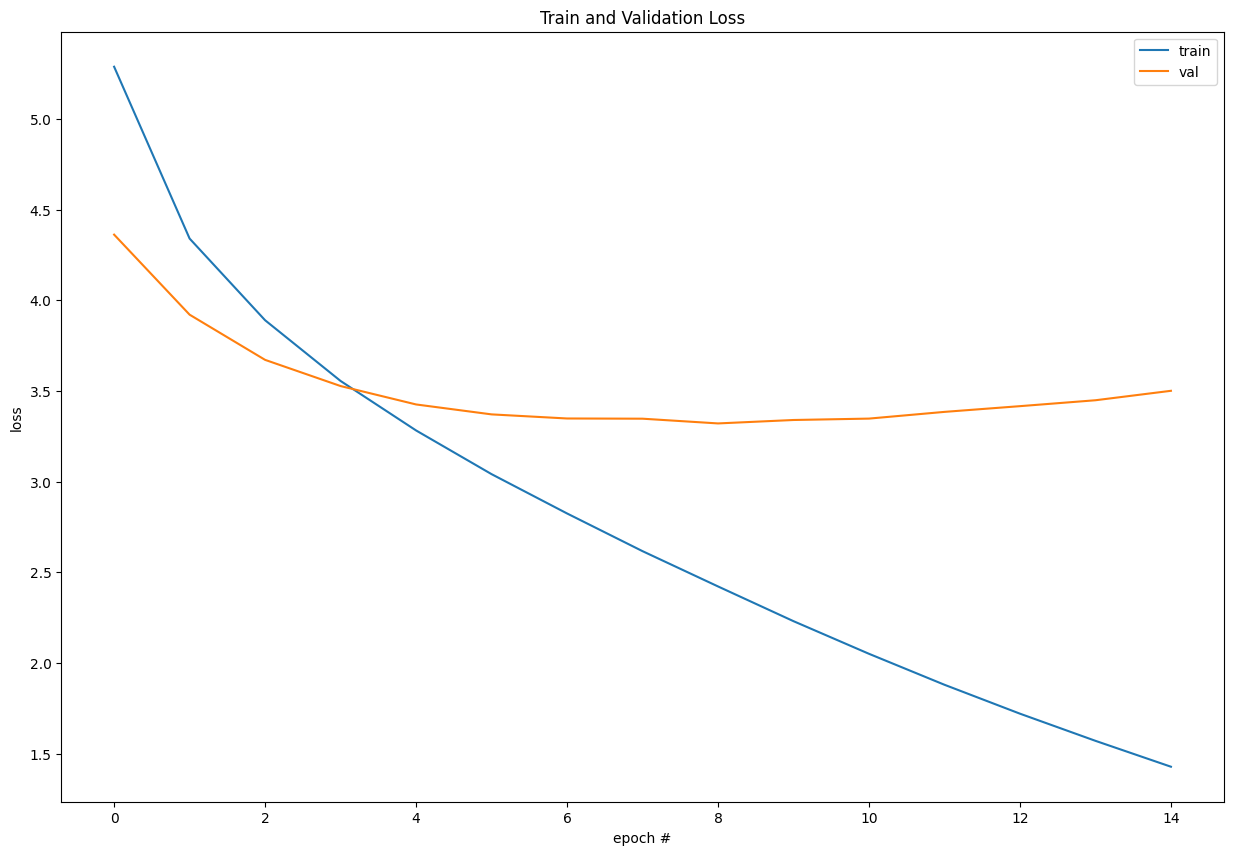

In [ ]:
# Plot the training and validation loss curves over epochs
plt.rcParams["figure.figsize"] = [15, 10]

pd.DataFrame(losses_en_es).plot(
    xlabel="epoch #",
    ylabel="loss",
    title="Train and Validation Loss",
)

### Evaluating translation quality with BLEU

Loss is useful for monitoring training, but it’s not a very interpretable
metric for translation quality. To compare different models and checkpoints in a
way that roughly matches human judgment, we use **BLEU** (Bilingual Evaluation
Understudy), here via the [`sacrebleu`](https://github.com/mjpost/sacrebleu) library.

At a high level, (unigram) BLEU:

- Compares the word counts in the system output (candidate translation) to
  the word counts in one or more human reference translations.
- Uses clipped counts so that a word repeated more times than in the
  references doesn’t get extra credit.
- Aggregates these matches over the whole corpus and applies a **brevity
  penalty** so that overly short translations are penalized.
- Produces a score between 0 and 1 (or 0 and 100 in some libraries), where
  higher is better.

#### Candidate and reference formats

The helper `translate_corpus` below translates all sentences in the test set
and returns:

- `candidate_text`: the model’s translations  
  Type: `List[List[str]]`  
  Each inner list is a single translated sentence as a list of word tokens, e.g:

  ```python
  candidate_text = [
      ["this", "is", "sentence", "one"],
      ["here", "is", "another", "mighty", "fine", "translation"],
  ]
  ```

* `reference_text`: the reference translations from the dataset
  Type: `List[List[List[str]]]`

  BLEU allows multiple reference translations for each candidate, so there’s
  an extra level of nesting: for each candidate sentence, we have a list of
  possible references. For example:

  ```python
  reference_text = [
      [
          # all reference translations for the first candidate
          ["this", "is", "sentence", "one"],
          ["here", "is", "another", "translation", "for", "sentence", "one"],
      ],
      [
          # all reference translations for the second candidate
          ["here", "is", "another", "mighty", "fine", "translation"],
      ],
  ]
  ```

In our setup, we only have one reference per sentence, so for each
candidate you’ll see a list containing a single reference:

```python
reference_text[i]  # → [ [w1, w2, ..., wK] ]
```

The `print_bleu` function will:

1. Join each candidate token list into a string.
2. Rearrange the references into the format expected by `sacrebleu.corpus_bleu`.
3. Compute the corpus-level BLEU score and print it (normalized to the
   0–1 range).

Below this markdown, `translate_corpus` and `print_bleu` implement this whole
pipeline using `sacrebleu` instead of `torchtext.bleu_score`.

In [ ]:
def translate_corpus(
    vocab: Dict[str, int],
    test_dl: DataLoader,
    model: nn.Module,
) -> Tuple[List[List[str]], List[List[List[str]]]]:
    """
    Run the model on the entire test set and collect candidate and reference
    translations in the format expected by BLEU.

    Args:
        vocab:   Target vocabulary mapping token → index.
        test_dl: DataLoader over the test split, yielding (source_batch, target_batch).
        model:   Trained Seq2Seq model with a .generate() method.

    Returns:
        candidate_text: List of candidate translations.
            Shape: [num_sentences][tokens]
        reference_text: List of reference translations.
            Shape: [num_sentences][num_refs][tokens]
            (here num_refs = 1, but BLEU allows multiple references per sentence)
    """
    # Invert vocab: index → token
    index_to_word = {v: k for k, v in vocab.items()}

    candidate_text: List[List[str]] = []
    reference_text: List[List[List[str]]] = []

    for source_batch, target_batch in test_dl:
        # Iterate over individual sentence pairs in the batch
        for source, target in zip(source_batch, target_batch):
            # Generate a translation. We cap length at 20 tokens
            # (the max length in this dataset is 14).
            translated_indices = model.generate(
                source,
                max_steps=20,
                eos_idx=EOS_IDX,
            )

            # Map token indices back to word strings
            new_candidate_text = [
                index_to_word[idx.item()] for idx in translated_indices
            ]

            # For references, BLEU expects a list of possible references per
            # sentence, even if there is only one.
            new_reference_text = [
                index_to_word[idx.item()] for idx in target
            ]
            new_reference_text = [new_reference_text]  # wrap in outer list

            candidate_text.append(new_candidate_text)
            reference_text.append(new_reference_text)

    return candidate_text, reference_text


def print_bleu(
    lang_name: str,
    train_ds,
    test_dl: DataLoader,
    model: nn.Module,
) -> None:
    """
    Compute and print the corpus-level BLEU score using sacrebleu.

    Args:
        lang_name: Human-readable label for the language pair (for printing).
        train_ds:  Training TranslationDataset (used here only for its target_vocab).
        test_dl:   DataLoader over the test split.
        model:     Trained Seq2Seq model to evaluate.
    """
    cand, refs = translate_corpus(train_ds.target_vocab, test_dl, model)
    # cand: [num_sentences][tokens]
    # refs: [num_sentences][num_refs][tokens]

    # 1) Candidates: join tokens into strings, one per sentence
    sys_stream = [" ".join(s) for s in cand]  # [N]

    # 2) References: arrange into [num_refs][N] for sacrebleu
    num_refs = len(refs[0])  # how many references per sentence (here, 1)
    ref_streams: List[List[str]] = []

    for j in range(num_refs):
        # For reference j, collect the j-th reference for every sentence i
        ref_streams.append(
            [" ".join(refs_i[j]) for refs_i in refs]
        )
    # ref_streams: [R][N], where R = num_refs

    # Compute BLEU with sacrebleu (returns score in [0, 100])
    bleu = sacrebleu.corpus_bleu(sys_stream, ref_streams)
    print(lang_name, bleu.score / 100.0)

In [ ]:
print_bleu("English -> Spanish", train_ds, test_dl, model_en_es)
# Example output:
# English -> Spanish 0.12619606701798783

English -> Spanish 0.11882101518983249


### Inspecting example translations (filtered and unfiltered)

BLEU gives us a single summary number, but it’s also important to look at *actual translations* to understand what the model is doing well (or badly).

The helper function `show_mixed_examples` prints a small set of English → Spanish examples from the test set in two modes:

1. **Filtered examples**  
   - We first filter out cases where the source or reference contain too many `<UNK>` tokens.
   - This gives us “cleaner” examples where the vocabulary is mostly known.
   - For each selected sentence, we print:
     - `SRC (EN)`: the English source sentence
     - `PRED(ES)`: the model’s Spanish prediction (generated with `model.generate`)
     - `REF (ES)`: the reference Spanish translation

2. **Unfiltered examples**  
   - We then sample some sentences with **no restriction** on `<UNK>` count.
   - This shows how the model behaves on more difficult or rare-word cases.

The helper `toks_from_ids` converts index sequences back into tokens, and removes padding and `<EOS>` markers so we see only “visible” words. Parameters like `max_steps`, `max_unk_filtered`, `n_filtered`, and `n_unfiltered` control how long the generated translations can be and how many examples of each type to display.


In [ ]:
@torch.no_grad()
def show_mixed_examples(
    train_ds,
    test_dl: DataLoader,
    model: nn.Module,
    max_steps: int = 20,
    max_unk_filtered: int = 1,
    n_filtered: int = 5,
    n_unfiltered: int = 5,
) -> None:
    """
    Print a mix of "clean" and "raw" English → Spanish translations
    from the test set.

    Args:
        train_ds:          Training TranslationDataset (used for vocab lookups).
        test_dl:           DataLoader over the test split.
        model:             Trained Seq2Seq model with .generate().
        max_steps:         Maximum number of decoding steps in generation.
        max_unk_filtered:  Maximum total number of <UNK> tokens allowed across
                           source and reference for an example to appear in the
                           filtered section.
        n_filtered:        Number of filtered examples to show.
        n_unfiltered:      Number of unfiltered examples to show.

    The function prints:
      - A block of "filtered" examples with few <UNK> tokens.
      - A block of "unfiltered" examples with no restrictions.
    """
    model.eval()

    # Build index → token maps for source (English) and target (Spanish)
    src_idx2word = {v: k for k, v in train_ds.source_vocab.items()}
    tgt_idx2word = {v: k for k, v in train_ds.target_vocab.items()}

    def toks_from_ids(ids: torch.Tensor, idx2word: Dict[int, str]) -> List[str]:
        """
        Convert a 1D tensor of token indices into a list of strings,
        filtering out padding and EOS tokens.
        """
        return [
            idx2word[i.item()]
            for i in ids
            if i.item() not in {PADDING_IDX, EOS_IDX}
        ]

    # -------- Filtered examples --------
    print(f"=== Filtered examples (max UNK = {max_unk_filtered}) ===")
    shown_filtered = 0

    for src_batch, tgt_batch in test_dl:
        for src, tgt in zip(src_batch, tgt_batch):
            src_tokens = toks_from_ids(src, src_idx2word)
            ref_tokens = toks_from_ids(tgt, tgt_idx2word)

            # Count unknowns in source + reference
            unk_count = src_tokens.count("<UNK>") + ref_tokens.count("<UNK>")
            if unk_count > max_unk_filtered:
                continue

            # Only generate once we know the example passes the UNK filter
            pred_ids = model.generate(
                src,
                max_steps=max_steps,
                eos_idx=EOS_IDX,
            )
            pred_tokens = toks_from_ids(pred_ids, tgt_idx2word)

            print("SRC (EN):", " ".join(src_tokens))
            print("PRED(ES):", " ".join(pred_tokens))
            print("REF (ES):", " ".join(ref_tokens))
            print("-" * 60)

            shown_filtered += 1
            if shown_filtered >= n_filtered:
                break

        if shown_filtered >= n_filtered:
            break

    # -------- Unfiltered examples --------
    print("=== Unfiltered examples (no UNK limit) ===")
    shown_unfiltered = 0

    for src_batch, tgt_batch in test_dl:
        for src, tgt in zip(src_batch, tgt_batch):
            src_tokens = toks_from_ids(src, src_idx2word)
            ref_tokens = toks_from_ids(tgt, tgt_idx2word)

            pred_ids = model.generate(
                src,
                max_steps=max_steps,
                eos_idx=EOS_IDX,
            )
            pred_tokens = toks_from_ids(pred_ids, tgt_idx2word)

            print("SRC (EN):", " ".join(src_tokens))
            print("PRED(ES):", " ".join(pred_tokens))
            print("REF (ES):", " ".join(ref_tokens))
            print("-" * 60)

            shown_unfiltered += 1
            if shown_unfiltered >= n_unfiltered:
                break

        if shown_unfiltered >= n_unfiltered:
            break


# Example usage on the English → Spanish model
show_mixed_examples(
    train_ds,
    test_dl,
    model_en_es,
    max_steps=20,
    max_unk_filtered=1,
    n_filtered=5,
    n_unfiltered=5,
)

=== Filtered examples (max UNK = 1) ===
SRC (EN): we are both independent partners in the partnership
PRED(ES): estamos en el punto de <UNK>
REF (ES): los dos somos socios independientes en la asociación
------------------------------------------------------------
SRC (EN): i am therefore calling on the commission to take action here too
PRED(ES): por tanto voy a votar en contra de la <UNK> de la comisión
REF (ES): por tanto pido a la comisión que actúe también a este respecto
------------------------------------------------------------
SRC (EN): i am grateful to the honourable member for taking up the question
PRED(ES): agradezco al comisario que haya <UNK> el debate
REF (ES): quedo agradecido a su señoría por haber planteado esta cuestión
------------------------------------------------------------
SRC (EN): we are doing our best
PRED(ES): estamos muy lejos de ello
REF (ES): estamos haciendo todo lo que podemos
------------------------------------------------------------
SRC (EN): we

### Qualitative look at English → Spanish translations

These examples again show the same general pattern: good parliamentary scaffolding, but shaky faithfulness when things get specific.

* On the **filtered** examples, the model often keeps the discourse frame but distorts the core meaning:

  * `we are both independent partners in the partnership`
    → `estamos en el punto de <UNK>`
    The idea of “both independent partners” disappears; we get a vague “we are at the point of …” instead of anything like *socios independientes*.
  * `i am therefore calling on the commission to take action here too`
    → `por tanto voy a votar en contra de la <UNK> de la comisión`
    The connective and “commission” are correct, but the stance flips: “calling on to act” becomes “going to vote against…”.
  * `i am grateful to the honourable member for taking up the question`
    → `agradezco al comisario que haya <UNK> el debate`
    The gratitude formula survives, but the roles and content shift (member → commissioner, question → debate, key verb hidden in `<UNK>`).

* When `<UNK>` appears, it tends to sit where important content should go, while templates stay fluent:

  * `we are going to discuss this later in the evening`
    → `vamos a <UNK> en el informe de la comisión`
    The future-discussion frame (`vamos a…`) is right, but “later in the evening” and the generic “this” become a hazy action about the Commission’s report.
  * `we are doing our best`
    → `estamos muy lejos de ello`
    Here the template is fluent but the meaning is inverted: “we’re doing our best” turns into “we’re far from it.”

* On the **unfiltered** examples, heavy `<UNK>` usage pushes the model toward very generic, sometimes off-target phrases:

  * `i am not advocating the harmonisation of all the sanctions`
    → `no soy el único <UNK>`
    Negation is preserved, but the specific policy stance collapses into “I’m not the only …”.
  * `i am sorry but i have to stop you`
    → `lo siento señor presidente`
    The apology and parliamentary address are there, but the crucial “have to stop you” constraint is gone.
  * `we are now discussing <UNK> s <UNK> status`
    → `ahora estamos <UNK> la <UNK> de <UNK>`
    The “now we’re talking about X’s status” frame reduces to “now we are <UNK> the <UNK> of <UNK>,” keeping only the time/discussion structure.

Overall, the model:

* Produces fluent, Europarl-style sentences with the right discourse markers and politeness formulas.
* Regularly loses or distorts key content words (roles, actions, polarity), especially when `<UNK>` hits important nouns/verbs.
* Under heavy unknowns, falls back to generic parliamentary boilerplate, which sounds plausible but weakens the link to the original English.


## 3. Extending to multiple source languages and the mystery language

Now that we’ve trained and inspected an English → Spanish model, we can reuse
the same architecture to probe the mystery language.

Recall that our pickled datasets contain parallel sentences for:

- Danish  
- English  
- German  
- Finnish  
- Spanish  
- `mystery`

The idea is:

- For each candidate source language (Danish, English, German, Finnish, Spanish),
  train a seq2seq model to translate **into** the `mystery` language.
- Compare their BLEU scores and training dynamics: if the mystery language is
  really just an encoded/codebook version of one of these languages, we expect that language → mystery model to perform noticeably better than the others.

To keep the setup for each language pair consistent, we use a small helper
function, `mystery_train_wrapper`, which:

1. Builds `TranslationDataset` objects for:
   - train: `<lang> → mystery`
   - validation: `<lang> → mystery`
   - test: `<lang> → mystery`
2. Shares the same source/target vocabularies across train/val/test for that pair.
3. Wraps each dataset in a `DataLoader` that uses our `pad_collate` function.

We’ll call this wrapper separately for each source language (Danish, English,
German, Finnish, Spanish) and then train a model for each pair.


In [ ]:
# Helper to create datasets and dataloaders for <lang> → mystery pairs
def mystery_train_wrapper(
    train_dict: Dict[str, List[List[str]]],
    val_dict: Dict[str, List[List[str]]],
    test_dict: Dict[str, List[List[str]]],
    lang: str,
):
    """
    Construct train/val/test TranslationDataset objects and corresponding
    DataLoaders for a given source language → mystery translation task.

    Args:
        train_dict: Dictionary for the training split, mapping language name
                    to list of tokenized sentences.
        val_dict:   Dictionary for the validation split (same structure).
        test_dict:  Dictionary for the test split (same structure).
        lang:       Name of the source language (e.g., 'danish', 'english').

    Returns:
        train_ds, val_ds, test_ds: TranslationDataset instances for
                                   <lang> → mystery.
        train_dl, val_dl, test_dl: DataLoaders for those datasets, using
                                   pad_collate and batch_size=32.
    """
    # Train dataset: build vocab from <lang> and 'mystery'
    train_ds = TranslationDataset(
        train_dict[lang],
        train_dict["mystery"],
    )

    # Validation and test datasets reuse the same vocabularies as train_ds
    val_ds = TranslationDataset(
        val_dict[lang],
        val_dict["mystery"],
        source_vocab=train_ds.source_vocab,
        target_vocab=train_ds.target_vocab,
    )
    test_ds = TranslationDataset(
        test_dict[lang],
        test_dict["mystery"],
        source_vocab=train_ds.source_vocab,
        target_vocab=train_ds.target_vocab,
    )

    # DataLoaders with our custom collate function for padding
    train_dl = DataLoader(
        train_ds,
        collate_fn=pad_collate,
        num_workers=0,
        shuffle=True,
        batch_size=32,
    )
    val_dl = DataLoader(
        val_ds,
        collate_fn=pad_collate,
        num_workers=0,
        shuffle=True,
        batch_size=32,
    )
    test_dl = DataLoader(
        test_ds,
        collate_fn=pad_collate,
        num_workers=0,
        shuffle=True,
        batch_size=32,
    )

    return train_ds, val_ds, test_ds, train_dl, val_dl, test_dl

### Training mystery-language models for each candidate source language

We’re now ready to train a separate seq2seq model for each candidate
source language → `mystery`:

- Danish → mystery  
- English → mystery  
- German → mystery  
- Finnish → mystery  
- Spanish → mystery  

For each language, we:

1. Use `mystery_train_wrapper(...)` to build:
   - `<lang> → mystery` train/validation/test `TranslationDataset` objects, and
   - corresponding `DataLoader`s with our padding collate function.
2. Call the same `train(...)` function we used for English → Spanish to:
   - Train the model with early stopping on validation loss.
   - Record the per-epoch train/validation losses for plotting later.

The code pattern is the same for every language: one block that prepares the
datasets/dataloaders with `mystery_train_wrapper`, followed by a call to
`train(...)` that returns a trained model and its loss history. Below is the
Danish example; similar cells are used for English, German, Finnish, and
Spanish.


In [ ]:
%%time
# Train Danish → mystery model
train_ds_danish, val_ds_danish, test_ds_danish, \
train_dl_danish, val_dl_danish, test_dl_danish = mystery_train_wrapper(
    train_dict,
    val_dict,
    test_dict,
    lang="danish",
)

model_danish, losses_danish = train(
    train_ds_danish,
    train_dl_danish,
    val_ds_danish,
    val_dl_danish,
)

Beginning training
[epoch 1,  80 batches] loss: 5.7569
[epoch 1, 160 batches] loss: 4.4961
Epoch 1: train=5.0895, val=3.9710
[epoch 2,  80 batches] loss: 3.9624
[epoch 2, 160 batches] loss: 3.6895
Epoch 2: train=3.8195, val=3.4234
[epoch 3,  80 batches] loss: 3.3637
[epoch 3, 160 batches] loss: 3.2577
Epoch 3: train=3.3053, val=3.1583
[epoch 4,  80 batches] loss: 2.9782
[epoch 4, 160 batches] loss: 2.9456
Epoch 4: train=2.9586, val=3.0074
[epoch 5,  80 batches] loss: 2.7101
[epoch 5, 160 batches] loss: 2.6788
Epoch 5: train=2.6938, val=2.8992
[epoch 6,  80 batches] loss: 2.4552
[epoch 6, 160 batches] loss: 2.5039
Epoch 6: train=2.4780, val=2.8389
[epoch 7,  80 batches] loss: 2.2845
[epoch 7, 160 batches] loss: 2.2982
Epoch 7: train=2.2926, val=2.8061
[epoch 8,  80 batches] loss: 2.0970
[epoch 8, 160 batches] loss: 2.1489
Epoch 8: train=2.1246, val=2.7842
[epoch 9,  80 batches] loss: 1.9512
[epoch 9, 160 batches] loss: 1.9937
Epoch 9: train=1.9723, val=2.7812
[epoch 10,  80 batches] los

<Axes: title={'center': 'Danish → Mystery: Train and Validation Loss'}, xlabel='epoch #', ylabel='loss'>

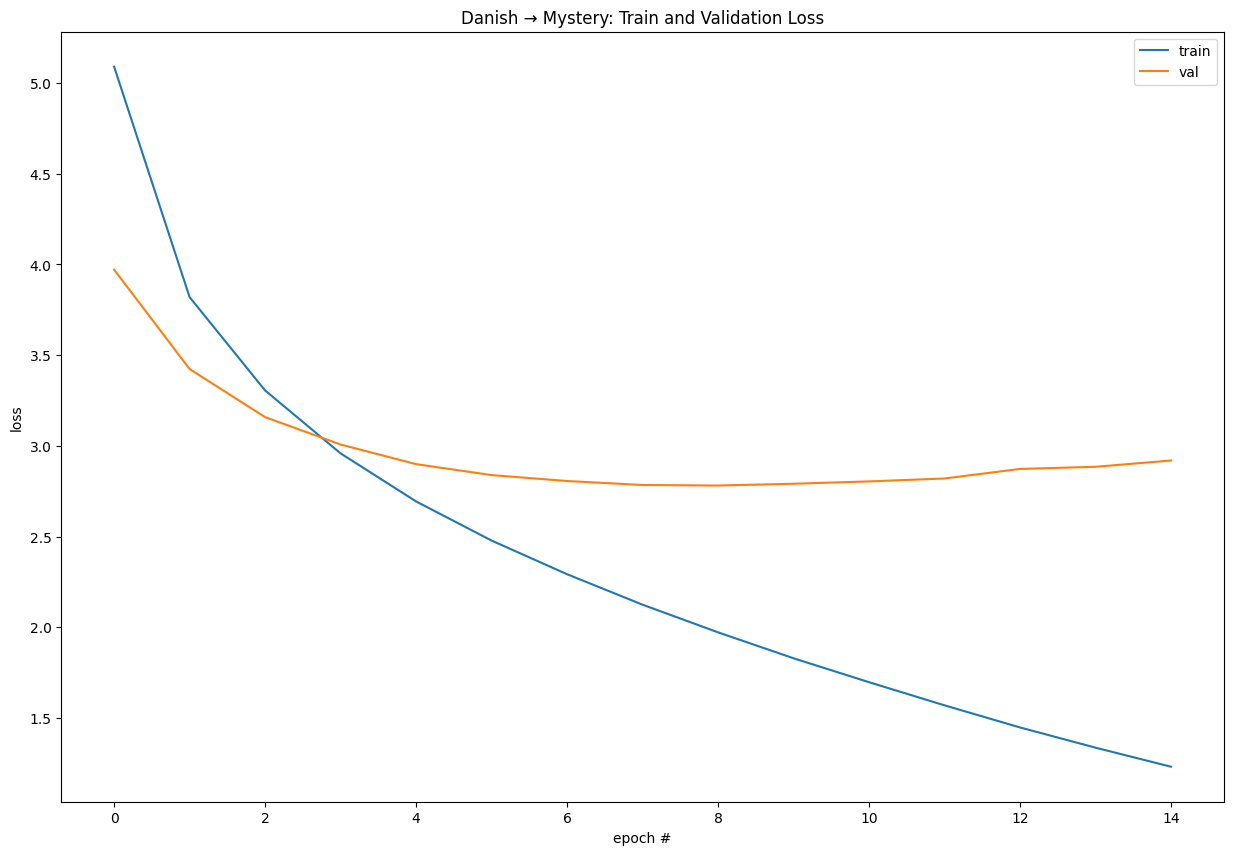

In [ ]:
# Plot Danish → mystery training and validation loss
plt.rcParams["figure.figsize"] = [15, 10]

pd.DataFrame(losses_danish).plot(
    xlabel="epoch #",
    ylabel="loss",
    title="Danish → Mystery: Train and Validation Loss",
)

In [ ]:
%%time
# Train English → mystery model
train_ds_english, val_ds_english, test_ds_english, \
train_dl_english, val_dl_english, test_dl_english = mystery_train_wrapper(
    train_dict,
    val_dict,
    test_dict,
    lang="english",
)

model_english, losses_english = train(
    train_ds_english,
    train_dl_english,
    val_ds_english,
    val_dl_english,
)

Beginning training
[epoch 1,  80 batches] loss: 5.7348
[epoch 1, 160 batches] loss: 4.5298
Epoch 1: train=5.0831, val=3.9458
[epoch 2,  80 batches] loss: 3.9374
[epoch 2, 160 batches] loss: 3.6644
Epoch 2: train=3.7888, val=3.3927
[epoch 3,  80 batches] loss: 3.2991
[epoch 3, 160 batches] loss: 3.2409
Epoch 3: train=3.2625, val=3.1237
[epoch 4,  80 batches] loss: 2.9508
[epoch 4, 160 batches] loss: 2.8764
Epoch 4: train=2.9119, val=2.9586
[epoch 5,  80 batches] loss: 2.6370
[epoch 5, 160 batches] loss: 2.6382
Epoch 5: train=2.6400, val=2.8590
[epoch 6,  80 batches] loss: 2.4108
[epoch 6, 160 batches] loss: 2.4088
Epoch 6: train=2.4154, val=2.7909
[epoch 7,  80 batches] loss: 2.2069
[epoch 7, 160 batches] loss: 2.2364
Epoch 7: train=2.2209, val=2.7636
[epoch 8,  80 batches] loss: 2.0288
[epoch 8, 160 batches] loss: 2.0613
Epoch 8: train=2.0466, val=2.7439
[epoch 9,  80 batches] loss: 1.8706
[epoch 9, 160 batches] loss: 1.8975
Epoch 9: train=1.8894, val=2.7389
[epoch 10,  80 batches] los

<Axes: title={'center': 'English → Mystery: Train and Validation Loss'}, xlabel='epoch #', ylabel='loss'>

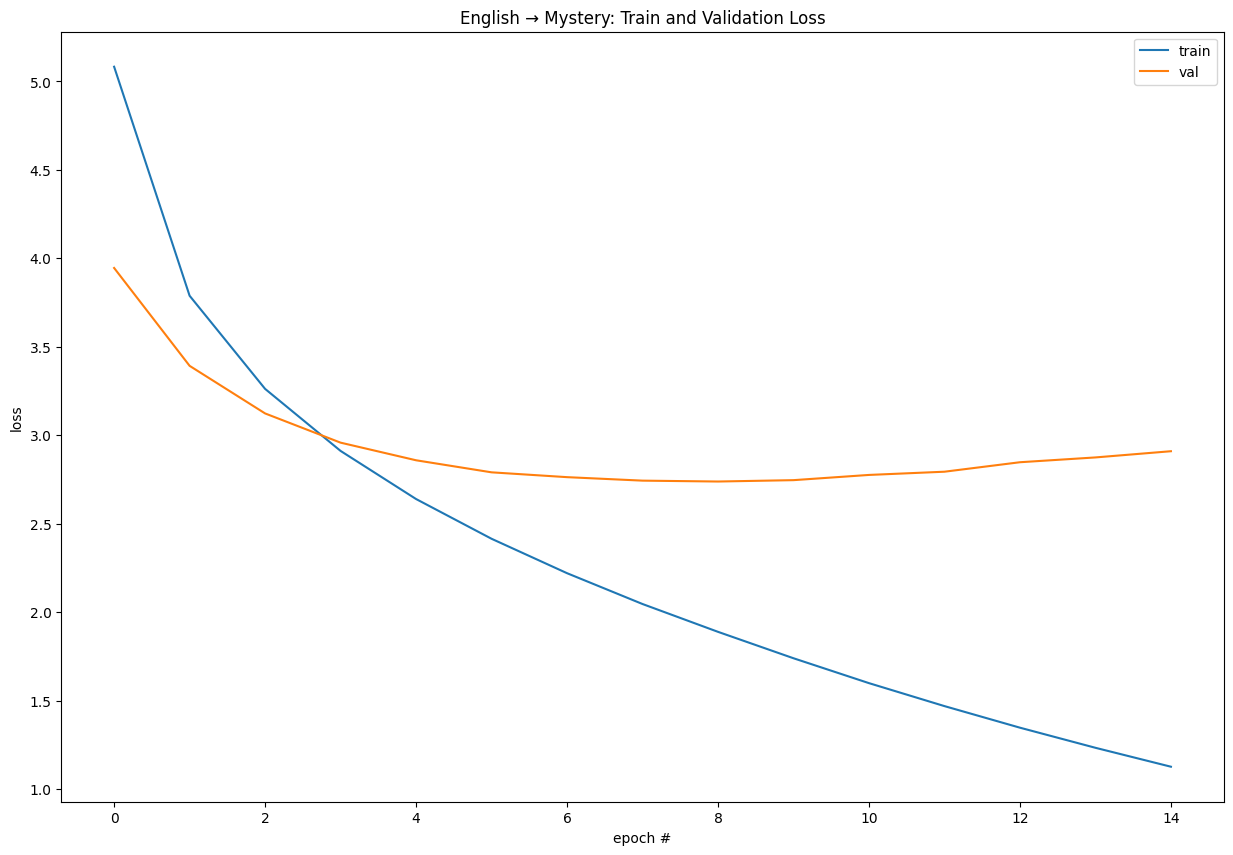

In [ ]:
# Plot English → mystery training and validation loss
plt.rcParams["figure.figsize"] = [15, 10]

pd.DataFrame(losses_english).plot(
    xlabel="epoch #",
    ylabel="loss",
    title="English → Mystery: Train and Validation Loss",
)

In [ ]:
%%time
# Train German → mystery model
train_ds_german, val_ds_german, test_ds_german, \
train_dl_german, val_dl_german, test_dl_german = mystery_train_wrapper(
    train_dict,
    val_dict,
    test_dict,
    lang="german",
)

model_german, losses_german = train(
    train_ds_german,
    train_dl_german,
    val_ds_german,
    val_dl_german,
)

Beginning training
[epoch 1,  80 batches] loss: 5.7381
[epoch 1, 160 batches] loss: 4.5169
Epoch 1: train=5.0826, val=3.9627
[epoch 2,  80 batches] loss: 3.9271
[epoch 2, 160 batches] loss: 3.7081
Epoch 2: train=3.8038, val=3.4120
[epoch 3,  80 batches] loss: 3.3513
[epoch 3, 160 batches] loss: 3.2437
Epoch 3: train=3.2918, val=3.1637
[epoch 4,  80 batches] loss: 2.9760
[epoch 4, 160 batches] loss: 2.9482
Epoch 4: train=2.9578, val=3.0048
[epoch 5,  80 batches] loss: 2.7169
[epoch 5, 160 batches] loss: 2.6859
Epoch 5: train=2.7020, val=2.9116
[epoch 6,  80 batches] loss: 2.4750
[epoch 6, 160 batches] loss: 2.4903
Epoch 6: train=2.4864, val=2.8570
[epoch 7,  80 batches] loss: 2.2997
[epoch 7, 160 batches] loss: 2.3024
Epoch 7: train=2.2995, val=2.8175
[epoch 8,  80 batches] loss: 2.1186
[epoch 8, 160 batches] loss: 2.1493
Epoch 8: train=2.1340, val=2.8026
[epoch 9,  80 batches] loss: 1.9485
[epoch 9, 160 batches] loss: 2.0063
Epoch 9: train=1.9796, val=2.8031
[epoch 10,  80 batches] los

<Axes: title={'center': 'German → Mystery: Train and Validation Loss'}, xlabel='epoch #', ylabel='loss'>

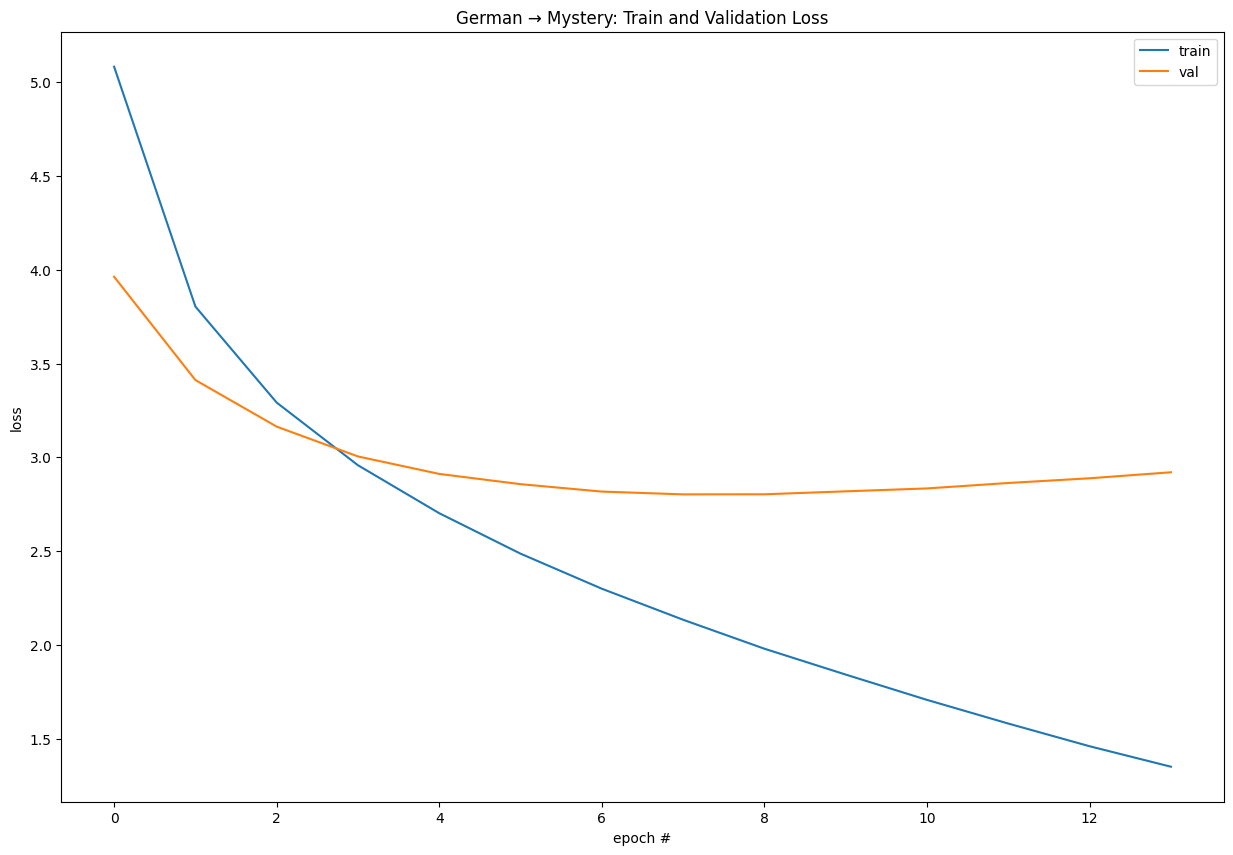

In [ ]:
# Plot German → mystery training and validation loss
plt.rcParams["figure.figsize"] = [15, 10]

pd.DataFrame(losses_german).plot(
    xlabel="epoch #",
    ylabel="loss",
    title="German → Mystery: Train and Validation Loss",
)

In [ ]:
%%time
# Train Finnish → mystery model
train_ds_finnish, val_ds_finnish, test_ds_finnish, \
train_dl_finnish, val_dl_finnish, test_dl_finnish = mystery_train_wrapper(
    train_dict,
    val_dict,
    test_dict,
    lang="finnish",
)

model_finnish, losses_finnish = train(
    train_ds_finnish,
    train_dl_finnish,
    val_ds_finnish,
    val_dl_finnish,
)

Beginning training
[epoch 1,  80 batches] loss: 5.7243
[epoch 1, 160 batches] loss: 4.4853
Epoch 1: train=5.0650, val=3.9432
[epoch 2,  80 batches] loss: 3.9466
[epoch 2, 160 batches] loss: 3.6911
Epoch 2: train=3.8081, val=3.4219
[epoch 3,  80 batches] loss: 3.3555
[epoch 3, 160 batches] loss: 3.2493
Epoch 3: train=3.3007, val=3.1634
[epoch 4,  80 batches] loss: 2.9796
[epoch 4, 160 batches] loss: 2.9545
Epoch 4: train=2.9627, val=3.0085
[epoch 5,  80 batches] loss: 2.6952
[epoch 5, 160 batches] loss: 2.7102
Epoch 5: train=2.7032, val=2.9084
[epoch 6,  80 batches] loss: 2.4862
[epoch 6, 160 batches] loss: 2.4811
Epoch 6: train=2.4894, val=2.8606
[epoch 7,  80 batches] loss: 2.2847
[epoch 7, 160 batches] loss: 2.3142
Epoch 7: train=2.2989, val=2.8156
[epoch 8,  80 batches] loss: 2.1045
[epoch 8, 160 batches] loss: 2.1473
Epoch 8: train=2.1294, val=2.8125
[epoch 9,  80 batches] loss: 1.9564
[epoch 9, 160 batches] loss: 1.9886
Epoch 9: train=1.9747, val=2.8138
[epoch 10,  80 batches] los

<Axes: title={'center': 'Finnish → Mystery: Train and Validation Loss'}, xlabel='epoch #', ylabel='loss'>

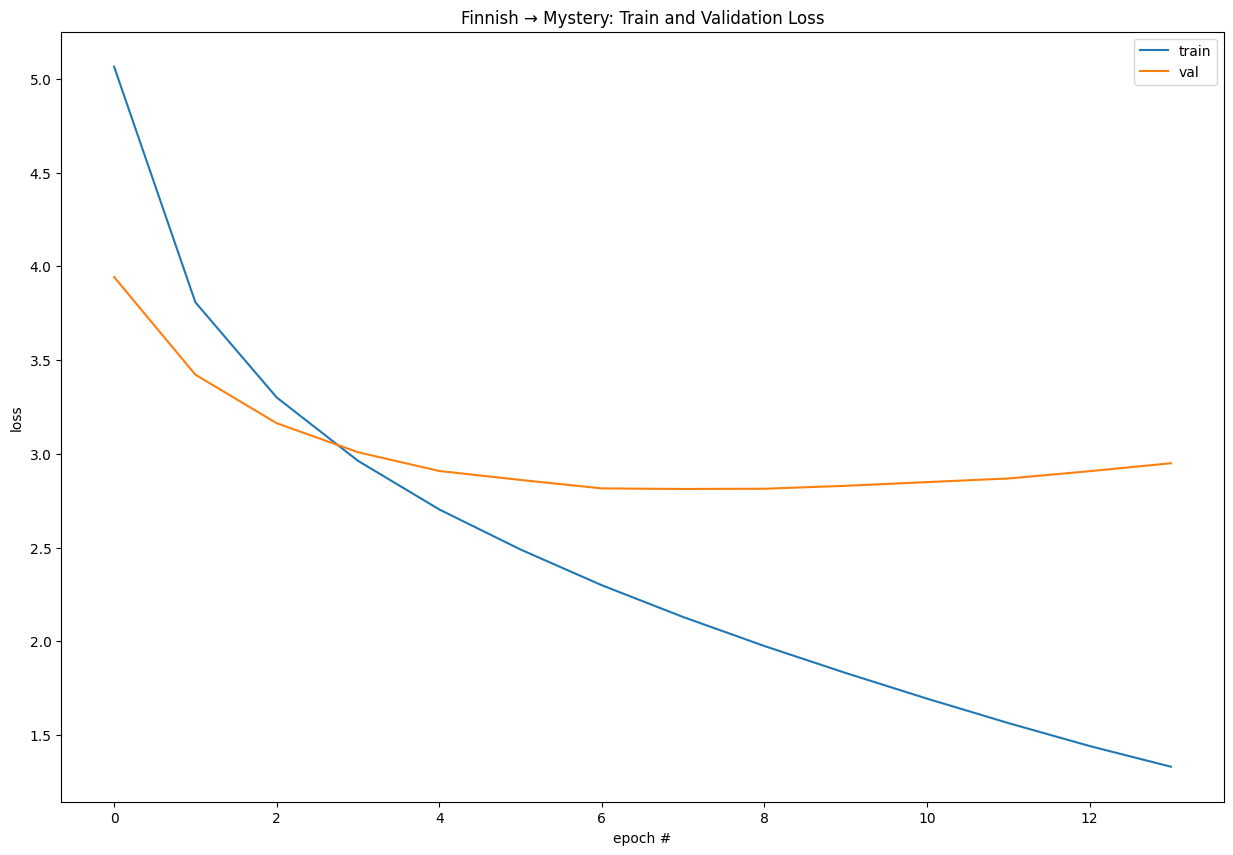

In [ ]:
# Plot Finnish → mystery training and validation loss
plt.rcParams["figure.figsize"] = [15, 10]

pd.DataFrame(losses_finnish).plot(
    xlabel="epoch #",
    ylabel="loss",
    title="Finnish → Mystery: Train and Validation Loss",
)

In [ ]:
%%time
# Train Spanish → mystery model
train_ds_spanish, val_ds_spanish, test_ds_spanish, \
train_dl_spanish, val_dl_spanish, test_dl_spanish = mystery_train_wrapper(
    train_dict,
    val_dict,
    test_dict,
    lang="spanish",
)

model_spanish, losses_spanish = train(
    train_ds_spanish,
    train_dl_spanish,
    val_ds_spanish,
    val_dl_spanish,
)

Beginning training
[epoch 1,  80 batches] loss: 5.7489
[epoch 1, 160 batches] loss: 4.5478
Epoch 1: train=5.1053, val=3.9654
[epoch 2,  80 batches] loss: 3.9252
[epoch 2, 160 batches] loss: 3.6139
Epoch 2: train=3.7585, val=3.2638
[epoch 3,  80 batches] loss: 3.2031
[epoch 3, 160 batches] loss: 3.0209
Epoch 3: train=3.1054, val=2.8628
[epoch 4,  80 batches] loss: 2.7159
[epoch 4, 160 batches] loss: 2.6161
Epoch 4: train=2.6562, val=2.6088
[epoch 5,  80 batches] loss: 2.3566
[epoch 5, 160 batches] loss: 2.2827
Epoch 5: train=2.3170, val=2.4395
[epoch 6,  80 batches] loss: 2.0658
[epoch 6, 160 batches] loss: 2.0372
Epoch 6: train=2.0485, val=2.3210
[epoch 7,  80 batches] loss: 1.8101
[epoch 7, 160 batches] loss: 1.8381
Epoch 7: train=1.8244, val=2.2356
[epoch 8,  80 batches] loss: 1.6198
[epoch 8, 160 batches] loss: 1.6432
Epoch 8: train=1.6332, val=2.1780
[epoch 9,  80 batches] loss: 1.4619
[epoch 9, 160 batches] loss: 1.4774
Epoch 9: train=1.4702, val=2.1361
[epoch 10,  80 batches] los

<Axes: title={'center': 'Spanish → Mystery: Train and Validation Loss'}, xlabel='epoch #', ylabel='loss'>

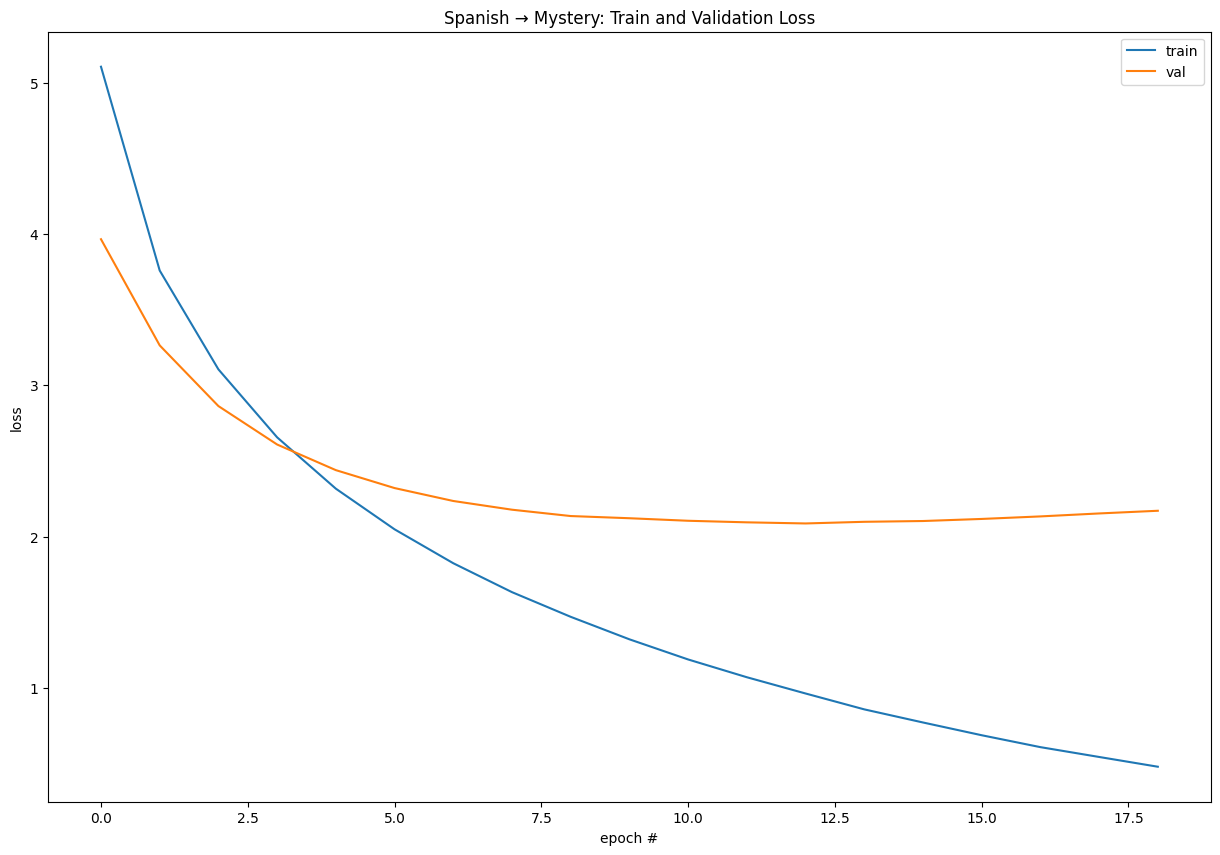

In [ ]:
# Plot Spanish → mystery training and validation loss
plt.rcParams["figure.figsize"] = [15, 10]

pd.DataFrame(losses_spanish).plot(
    xlabel="epoch #",
    ylabel="loss",
    title="Spanish → Mystery: Train and Validation Loss",
)

### Comparing BLEU scores across candidate source languages

Now that we have trained five separate models

- Danish → mystery  
- English → mystery  
- German → mystery  
- Finnish → mystery  
- Spanish → mystery  

we can evaluate all of them on their respective test sets using corpus-level BLEU.

Intuitively, if the mystery language is really an obfuscated or encoded version of one particular language, the model trained on that true source → mystery pair should achieve a noticeably higher BLEU score than the others. In our case, we expect the Spanish → mystery model to stand out if the mystery text is a codebook version of Spanish.

The cell below computes and prints the BLEU score for each candidate source language, using the same `print_bleu` helper as before.


In [ ]:
# Evaluate BLEU scores for all five source -> mystery models
print_bleu("Danish",  train_ds_danish,  test_dl_danish,  model_danish)
print_bleu("English", train_ds_english, test_dl_english, model_english)
print_bleu("German",  train_ds_german,  test_dl_german,  model_german)
print_bleu("Finnish", train_ds_finnish, test_dl_finnish, model_finnish)
print_bleu("Spanish", train_ds_spanish, test_dl_spanish, model_spanish)

Danish 0.09466083692632615
English 0.0890938399088225
German 0.09024698877418512
Finnish 0.08327546157337583
Spanish 0.10682095548553378


### The mystery language is Spanish by a hair. With a BLEU score of 0.107, just 12% higher than the next highest language Danish.

### What is the mystery cipher, and why is it lossy?

The `mystery` language in this notebook is not a natural language at all, but a codebook cipher applied to Spanish:

- Each Spanish word type is assigned a random “code” string.
- That code can consist of one or more whitespace-separated tokens (e.g., a single token like `qdy` or a multi-token sequence like `a bism`).
- Sentences are formed by replacing each Spanish word with its corresponding code sequence.

At first glance, this looks like a reversible substitution: if we knew the full codebook, we could just invert the mapping. In practice, several design choices in the cipher make perfect recovery impossible, even with access to the entire corpus.

#### 1. Spaces and segmentation ambiguity

Because codes can span multiple tokens and are separated by spaces, the decoder faces a segmentation problem:

- Some codes are single tokens, others are multi-token phrases.
- Worse, a valid code can be the prefix of another valid code, e.g.  
  `a` is a complete code, but `a bism` is also a complete code.

When you scan a mystery sentence from left to right, you must decide whether `a` alone is a code, or whether you should group `a bism` as a longer code. There are hundreds of such prefix overlaps. Any simple “greedy” decoding that always takes the shortest or longest match will make systematic mistakes, and even a smart decoder can’t always disambiguate purely from local context.

So the spaces themselves are part of the cipher: they don’t cleanly separate words, they separate *code tokens*, and those tokens don’t uniquely specify segmentation.

#### 2. Missing entries in the effective codebook

Some Spanish words are so rare, or so tightly bound to others, that the data never gives us enough information to distinguish them:

- Certain rare words only ever appear in a fixed collocation (e.g., word A and word B always appear together in the same sentence and never separately).
- On the mystery side, the corresponding code sequence is always seen as a single chunk; we never see A’s code or B’s code in isolation.

Even with perfect logical “Sudoku-style” elimination, we can get stuck in logical deadlocks: there are multiple assignments of codes to words that are consistent with all observed sentences. In those cases, the codebook cannot be uniquely completed from data alone, so some entries remain effectively undetermined.

#### 3. Collisions: different words, same code

The most fundamental problem is that the cipher is not injective:

- In the corpus, we can find explicit collisions, where the *same* mystery code string is aligned to two different Spanish words in different sentences.
- For example (from the analysis notebook), a single code token `q` appears aligned once to *opongo* and once to *responsable*.

This is genuine **information loss**: if both sentences appear as `q` on the mystery side, there is no way—purely from the ciphered text—to know whether the intended word was *opongo* or *responsable* in any new sentence. Any decoder must pick one (usually the more frequent), and will be wrong whenever the rarer word was intended.

#### Putting it together: a lossy code

These three issues interact:

- **Segmentation ambiguity** from multi-token codes and prefix overlaps.
- **Missing or underdetermined entries** for rare / collocated words.
- **True collisions**, where distinct Spanish words share the same code.

Even with a very strong hybrid solver (statistics + logical elimination) and access to all train/val/test data, you can push the recoverable portion of the codebook only to about 96%. The remaining cases require guessing based on context or frequency, not pure inversion of the cipher.

In other words, the mystery cipher is *lossy by design*: it does not preserve enough information for 100% exact reconstruction of the original Spanish text. This explains why, even though Spanish → mystery is clearly the “right” pairing, our seq2seq model’s BLEU score can never reach 1.0. The underlying signal itself has been irreversibly compressed and blurred by the codebook.


### Comparing training dynamics across language pairs

To get a side-by-side view of how each language pair behaves during training, we can plot the train and validation loss curves for all five source → mystery models in a single grid.

A few patterns are worth noticing:

- For Danish, English, German, and Finnish, the validation loss drops at first and then flattens out around a relatively high value, even as the training loss continues to decrease. This suggests the models are fitting their training data but have limited ability to generalize to the validation set.
- In contrast, the Spanish → mystery model shows both training and validation loss dropping much further and stabilizing at clearly lower values than the other languages.
- The gap between train and validation curves for Spanish is also smaller and more stable, which is what we’d expect when the source language is genuinely well aligned with the mystery language.

Taken together, these training histories already hint that Spanish is the best match for the mystery language, even without looking at BLEU scores.


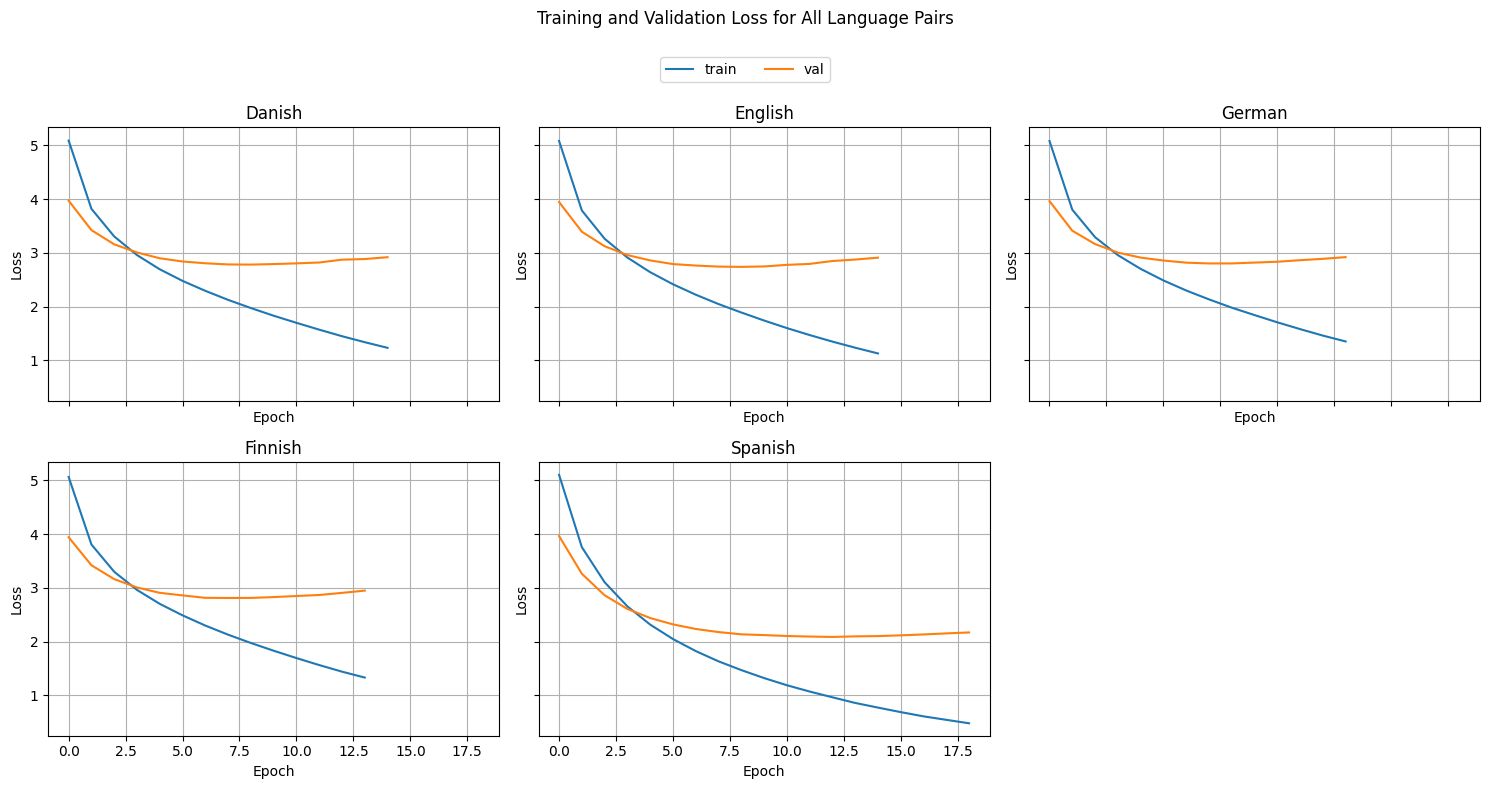

In [ ]:
# Compare all 5 language training histories visually in a 2x3 grid
histories = {
    "Danish":  losses_danish,
    "English": losses_english,
    "German":  losses_german,
    "Finnish": losses_finnish,
    "Spanish": losses_spanish,
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, (lang, hist) in zip(axes, histories.items()):
    df = pd.DataFrame(hist)  # expects keys "train" and "val"
    ax.plot(df.index, df["train"], label="train")
    ax.plot(df.index, df["val"],   label="val")
    ax.set_title(lang)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True)

# Hide any unused subplot (since we only have 5 languages)
if len(histories) < len(axes):
    for j in range(len(histories), len(axes)):
        fig.delaxes(axes[j])

# Layout: leave space at top for title + legend
fig.tight_layout(rect=[0, 0, 1, 0.88])

# Shared title
fig.suptitle("Training and Validation Loss for All Language Pairs", y=0.98)

# Shared legend just under the title
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="upper center",
           ncol=2,
           bbox_to_anchor=(0.5, 0.93))

plt.show()

### Why does Spanish → mystery still get the best BLEU?

At this point we know two things:

1. The mystery language is a codebook cipher applied to Spanish.
2. The cipher is lossy: it has segmentation ambiguity, missing or underdetermined entries, and collisions where multiple Spanish words share the same code.

So why does the Spanish → mystery model still achieve a much higher BLEU score than Danish/German/Finnish/English → mystery?

There are a few key reasons.

1. **Forward mapping is consistent, even if inverse mapping is not**

   The codebook is problematic when you try to go from mystery back to Spanish. But in the *forward* direction, Spanish → mystery, the mapping is perfectly well defined:

   - Each Spanish word has a fixed code sequence on the mystery side.
   - Collisions mean that two Spanish words share the same code, but they do not create ambiguity when going forward: both words just map to that same output.

   From the model’s perspective, Spanish → mystery is “just” learning a strange but consistent target language. The training data always shows the same Spanish input aligned to the same mystery output, so the model can approximate that mapping quite well.

2. **Other languages must implicitly learn two mappings at once**

   For a non-Spanish source language (say Danish), the underlying generative story is closer to:

   > Danish → Spanish (human translation) → cipher(Spanish) = mystery

   But the model only sees:

   > Danish input → mystery output

   To succeed, a Danish → mystery model has to internally approximate both parts of the pipeline:

   - A proper translation from Danish into (something like) Spanish.
   - The exotic Spanish → code mapping on top of that.

   That is strictly harder than learning Spanish → code directly. Any errors in the implicit “Danish → Spanish” step show up as wrong codes on the mystery side, dragging BLEU down.

3. **Word order and structure are already aligned for Spanish**

   The codebook was built on Spanish sentences, so:

   - Word order, morphology, and sentence length of the mystery text are closely tied to Spanish.
   - For Spanish → mystery, the model can often stay near monotonic: source and target positions roughly line up.

   For other languages, the model has to deal with extra reordering and structural differences before it can even try to match the code tokens. That extra complexity again lowers BLEU.

4. **Lossiness caps the ceiling but not the ranking**

   The lossy parts of the cipher (collisions, ambiguous segmentations, rare words) hurt *every* model equally in the sense that even a perfect Spanish → mystery system cannot reach BLEU = 1.0:

   - Whenever two Spanish words share the same code, no model can produce outputs that uniquely preserve the original choice.
   - Ambiguous multi-token codes and underdetermined entries create irreducible uncertainty in the target sequences.

   This effectively lowers the maximum achievable BLEU for the “correct” language pair, but it does not give any advantage to the *wrong* language pairs. Spanish → mystery is still the one that can best match the observed code sequences; the others are fighting both the normal translation problem and the weirdness of the cipher.

The cipher being lossy explains why Spanish → mystery cannot achieve very high absolute BLEU, but the mapping is still far easier to learn from Spanish than from Danish, English, German, or Finnish. That is why Spanish → mystery stands out clearly in both the loss curves and the BLEU scores, even though perfect reconstruction of the original Spanish is provably impossible.
